<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Microwave_RF_Filter_Layouts_PHIDL_GDSTK_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## PHIDL and GDSTK microwave/RF filter layout notebook

This notebook generates first-pass planar microwave/RF filter layouts with PHIDL, exports each filter as an OASIS file with GDSTK, and renders a synthesis-level expected response curve in the same code cell as the layout. The geometries are deliberately parameterized so the defaults can be adjusted for another substrate, center frequency, filter order, or line impedance.

The response curves are idealized network-synthesis estimates. They are useful for layout sanity checks before electromagnetic extraction with a field solver.


In [1]:
INSTALL_PACKAGES = True

if INSTALL_PACKAGES:
    !uv pip install -q numpy scipy matplotlib phidl gdspy gdstk

In [2]:
"""Generate microwave/RF filter layouts and expected response curves.

PHIDL can provide editable polygon geometries. Meanwhile, GDSTK writes OASIS files.
NumPy and SciPy can compute idealized distributed-network and prototype responses.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import numpy as np
from phidl import Device
from scipy import signal

# =============================================================================
# CONTROL KNOBS
# =============================================================================

MPL_DPI = 250
OUTPUT_DIR = Path("oas_filter_layouts")

METAL_LAYER = 1
VIA_LAYER = 2
OUTLINE_LAYER = 10

C0_M_PER_S = 299_792_458.0
PLOT_RESPONSE_FLOOR_DB = -80.0

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI


@dataclass(frozen=True)
class SubstrateSpec:
    """Planar substrate parameters used by the microstrip estimates."""

    name: str = "Rogers_4350B_10mil"
    relative_permittivity: float = 3.66
    thickness_um: float = 254.0


@dataclass(frozen=True)
class SweepSpec:
    """Frequency sweep parameters in GHz."""

    start_ghz: float
    stop_ghz: float
    points: int = 1201


def make_frequency_axis(spec: SweepSpec) -> np.ndarray:
    """Return a linear frequency grid in GHz."""

    return np.linspace(spec.start_ghz, spec.stop_ghz, spec.points)


def effective_permittivity(width_um: float, substrate: SubstrateSpec) -> float:
    """Estimate the quasi-static microstrip effective permittivity."""

    wh_ratio = width_um / substrate.thickness_um
    base = (substrate.relative_permittivity + 1.0) / 2.0
    contrast = (substrate.relative_permittivity - 1.0) / 2.0
    correction = 0.0

    if wh_ratio < 1.0:
        correction = 0.04 * (1.0 - wh_ratio) ** 2

    return base + contrast * (
        1.0 / np.sqrt(1.0 + 12.0 / wh_ratio) + correction
    )


def z0_from_width_um(width_um: float, substrate: SubstrateSpec) -> float:
    """Estimate microstrip characteristic impedance in ohms."""

    wh_ratio = width_um / substrate.thickness_um
    eps_eff = effective_permittivity(width_um, substrate)

    if wh_ratio <= 1.0:
        return (60.0 / np.sqrt(eps_eff)) * np.log(
            8.0 / wh_ratio + 0.25 * wh_ratio
        )

    denominator = wh_ratio + 1.393 + 0.667 * np.log(wh_ratio + 1.444)
    return 120.0 * np.pi / (np.sqrt(eps_eff) * denominator)


def width_for_impedance_um(
    target_z0_ohm: float,
    substrate: SubstrateSpec,
    iterations: int = 80,
) -> float:
    """Find the microstrip width that produces a target impedance."""

    low_ratio = 0.02
    high_ratio = 80.0

    for _ in range(iterations):
        mid_ratio = 0.5 * (low_ratio + high_ratio)
        width_um = mid_ratio * substrate.thickness_um
        z_mid = z0_from_width_um(width_um, substrate)

        if z_mid > target_z0_ohm:
            low_ratio = mid_ratio
        else:
            high_ratio = mid_ratio

    return 0.5 * (low_ratio + high_ratio) * substrate.thickness_um


def guided_wavelength_um(
    frequency_ghz: float,
    z0_ohm: float,
    substrate: SubstrateSpec,
) -> float:
    """Estimate guided wavelength in micrometers."""

    width_um = width_for_impedance_um(z0_ohm, substrate)
    eps_eff = effective_permittivity(width_um, substrate)
    wavelength_m = C0_M_PER_S / (frequency_ghz * 1.0e9 * np.sqrt(eps_eff))
    return wavelength_m * 1.0e6


def electrical_length_to_um(
    electrical_length_rad: float,
    frequency_ghz: float,
    z0_ohm: float,
    substrate: SubstrateSpec,
) -> float:
    """Convert electrical length in radians to physical length in micrometers."""

    lambda_g_um = guided_wavelength_um(frequency_ghz, z0_ohm, substrate)
    return electrical_length_rad * lambda_g_um / (2.0 * np.pi)


def sanitize_cell_name(name: str) -> str:
    """Return a cell name accepted by common layout tools."""

    cleaned = "".join(ch if ch.isalnum() else "_" for ch in name)
    cleaned = "_".join(part for part in cleaned.split("_") if len(part) > 0)
    return cleaned[:64]


def add_rectangle(
    device: Device,
    x_um: float,
    y_um: float,
    width_um: float,
    height_um: float,
    layer: int = METAL_LAYER,
) -> None:
    """Add an axis-aligned rectangle to a PHIDL device."""

    points = [
        (x_um, y_um),
        (x_um + width_um, y_um),
        (x_um + width_um, y_um + height_um),
        (x_um, y_um + height_um),
    ]
    device.add_polygon(points, layer=layer)


def add_centered_line(
    device: Device,
    x_um: float,
    y_center_um: float,
    length_um: float,
    width_um: float,
    layer: int = METAL_LAYER,
) -> None:
    """Add a horizontal line segment centered about y_center_um."""

    add_rectangle(
        device=device,
        x_um=x_um,
        y_um=y_center_um - 0.5 * width_um,
        width_um=length_um,
        height_um=width_um,
        layer=layer,
    )


def add_vertical_line(
    device: Device,
    x_center_um: float,
    y_um: float,
    length_um: float,
    width_um: float,
    layer: int = METAL_LAYER,
) -> None:
    """Add a vertical line segment centered about x_center_um."""

    add_rectangle(
        device=device,
        x_um=x_center_um - 0.5 * width_um,
        y_um=y_um,
        width_um=width_um,
        height_um=length_um,
        layer=layer,
    )


def add_outline(device: Device, margin_um: float = 1000.0) -> None:
    """Add a substrate keep-out outline on a separate layer."""

    bbox = np.asarray(device.bbox, dtype=float)
    xmin = float(bbox[0, 0] - margin_um)
    ymin = float(bbox[0, 1] - margin_um)
    xmax = float(bbox[1, 0] + margin_um)
    ymax = float(bbox[1, 1] + margin_um)

    add_rectangle(
        device=device,
        x_um=xmin,
        y_um=ymin,
        width_um=xmax - xmin,
        height_um=ymax - ymin,
        layer=OUTLINE_LAYER,
    )


def save_oasis_from_device(device: Device, output_dir: Path = OUTPUT_DIR) -> Path:
    """Write a PHIDL device to an OASIS file through GDSTK."""

    output_dir.mkdir(parents=True, exist_ok=True)
    cell_name = sanitize_cell_name(device.name)
    output_path = output_dir / f"{cell_name}.oas"

    library = gdstk.Library(unit=1.0e-6, precision=1.0e-9)
    cell = library.new_cell(cell_name)
    polygon_dict = device.get_polygons(by_spec=True)

    for spec, polygons in polygon_dict.items():
        if isinstance(spec, tuple):
            layer = int(spec[0])
            datatype = int(spec[1])
        else:
            layer = int(spec)
            datatype = 0

        for polygon in polygons:
            points = np.asarray(polygon, dtype=float)
            cell.add(gdstk.Polygon(points, layer=layer, datatype=datatype))

    library.write_oas(str(output_path))
    return output_path


def plot_device_and_response(
    device: Device,
    frequency_ghz: np.ndarray,
    s21_db: np.ndarray,
    title: str,
    output_path: Path,
) -> None:
    """Render a layout and expected S21 response in a single figure."""

    polygon_dict = device.get_polygons(by_spec=True)
    layer_order = {OUTLINE_LAYER: 0, METAL_LAYER: 1, VIA_LAYER: 2}
    layer_styles = {
        OUTLINE_LAYER: ("0.94", "0.78", 0.7),
        METAL_LAYER: ("black", "black", 1.0),
        VIA_LAYER: ("blue", "blue", 1.0),
    }

    fig, (ax_layout, ax_response) = plt.subplots(
        1,
        2,
        figsize=(12.0, 4.6),
        constrained_layout=True,
    )

    for spec in sorted(
        polygon_dict.keys(),
        key=lambda item: layer_order.get(item[0] if isinstance(item, tuple) else item, 99),
    ):
        layer = int(spec[0]) if isinstance(spec, tuple) else int(spec)
        face_color, edge_color, alpha = layer_styles.get(layer, ("0.55", "black", 0.9))

        for polygon in polygon_dict[spec]:
            patch = MplPolygon(
                np.asarray(polygon),
                closed=True,
                facecolor=face_color,
                edgecolor=edge_color,
                linewidth=0.7,
                alpha=alpha,
            )
            ax_layout.add_patch(patch)

    bbox = np.asarray(device.bbox, dtype=float)
    xmin, ymin = bbox[0]
    xmax, ymax = bbox[1]
    dx = max(float(xmax - xmin), 1.0)
    dy = max(float(ymax - ymin), 1.0)
    ax_layout.set_xlim(float(xmin - 0.05 * dx), float(xmax + 0.05 * dx))
    ax_layout.set_ylim(float(ymin - 0.08 * dy), float(ymax + 0.08 * dy))
    ax_layout.set_aspect("equal", adjustable="box")
    ax_layout.set_title(f"{title}\nSaved as {output_path.name}")
    ax_layout.set_xlabel("x (µm)")
    ax_layout.set_ylabel("y (µm)")

    ax_response.plot(frequency_ghz, np.maximum(s21_db, PLOT_RESPONSE_FLOOR_DB), color="blue", lw=2.0)
    ax_response.axhline(-3.0, color="black", lw=0.9, ls=":")
    ax_response.set_title("Expected idealized response")
    ax_response.set_xlabel("Frequency (GHz)")
    ax_response.set_ylabel(r"$|S_{21}|$ (dB)")
    ax_response.set_ylim(PLOT_RESPONSE_FLOOR_DB, 5.0)
    ax_response.grid(True, alpha=0.3)

    plt.show()


def abcd_identity(length: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return vectorized ABCD identity coefficients."""

    one = np.ones(length, dtype=np.complex128)
    zero = np.zeros(length, dtype=np.complex128)
    return one.copy(), zero.copy(), zero.copy(), one.copy()


def cascade_abcd(
    first: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    second: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Cascade two vectorized ABCD two-port networks."""

    a1, b1, c1, d1 = first
    a2, b2, c2, d2 = second

    a_total = a1 * a2 + b1 * c2
    b_total = a1 * b2 + b1 * d2
    c_total = c1 * a2 + d1 * c2
    d_total = c1 * b2 + d1 * d2
    return a_total, b_total, c_total, d_total


def line_abcd(
    z0_ohm: float,
    theta_rad: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return ABCD parameters for a lossless transmission line."""

    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)

    a_value = cos_theta.astype(np.complex128)
    b_value = 1j * z0_ohm * sin_theta
    c_value = 1j * sin_theta / z0_ohm
    d_value = cos_theta.astype(np.complex128)
    return a_value, b_value, c_value, d_value


def shunt_admittance_abcd(
    admittance_s: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return ABCD parameters for a shunt admittance."""

    one = np.ones_like(admittance_s, dtype=np.complex128)
    zero = np.zeros_like(admittance_s, dtype=np.complex128)
    return one, zero, admittance_s.astype(np.complex128), one.copy()


def s21_from_abcd(
    network: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    port_z0_ohm: float = 50.0,
) -> np.ndarray:
    """Convert ABCD parameters to forward transmission for equal terminations."""

    a_value, b_value, c_value, d_value = network
    denominator = a_value + b_value / port_z0_ohm + c_value * port_z0_ohm + d_value
    return 2.0 / denominator


def s21_db_from_complex(s21: np.ndarray) -> np.ndarray:
    """Convert complex S21 values to dB magnitude."""

    magnitude = np.maximum(np.abs(s21), 1.0e-14)
    return 20.0 * np.log10(magnitude)


def butterworth_g_values(order: int) -> list[float]:
    """Return normalized Butterworth low-pass prototype element values."""

    return [
        2.0 * np.sin((2.0 * index - 1.0) * np.pi / (2.0 * order))
        for index in range(1, order + 1)
    ]


def stepped_impedance_response_db(
    frequency_ghz: np.ndarray,
    cutoff_ghz: float,
    prototype_g: Sequence[float],
    source_z0_ohm: float,
    high_z0_ohm: float,
    low_z0_ohm: float,
) -> np.ndarray:
    """Compute the response of a stepped-impedance low-pass approximation."""

    network = abcd_identity(len(frequency_ghz))

    for index, g_value in enumerate(prototype_g, start=1):
        if index % 2 == 1:
            section_z0 = high_z0_ohm
            theta_cutoff = g_value * source_z0_ohm / high_z0_ohm
        else:
            section_z0 = low_z0_ohm
            theta_cutoff = g_value * low_z0_ohm / source_z0_ohm

        theta = theta_cutoff * frequency_ghz / cutoff_ghz
        network = cascade_abcd(network, line_abcd(section_z0, theta))

    return s21_db_from_complex(s21_from_abcd(network, source_z0_ohm))


def open_or_short_stub_response_db(
    frequency_ghz: np.ndarray,
    center_ghz: float,
    number_of_stubs: int,
    main_z0_ohm: float,
    stub_z0_ohm: float,
    stub_kind: str,
) -> np.ndarray:
    """Compute an idealized shunt-stub filter response."""

    theta_quarter = 0.5 * np.pi * frequency_ghz / center_ghz
    theta_end = 0.25 * np.pi * frequency_ghz / center_ghz
    tangent = np.tan(theta_quarter)
    safe_tangent = np.where(np.abs(tangent) < 1.0e-12, 1.0e-12, tangent)

    if stub_kind == "open":
        stub_admittance = 1j * tangent / stub_z0_ohm
    elif stub_kind == "short":
        stub_admittance = -1j / (stub_z0_ohm * safe_tangent)
    else:
        raise ValueError("stub_kind must be either 'open' or 'short'.")

    network = abcd_identity(len(frequency_ghz))
    network = cascade_abcd(network, line_abcd(main_z0_ohm, theta_end))

    for index in range(number_of_stubs):
        network = cascade_abcd(network, shunt_admittance_abcd(stub_admittance))

        if index < number_of_stubs - 1:
            network = cascade_abcd(network, line_abcd(main_z0_ohm, theta_quarter))

    network = cascade_abcd(network, line_abcd(main_z0_ohm, theta_end))
    return s21_db_from_complex(s21_from_abcd(network, main_z0_ohm))


def chebyshev_bandpass_response_db(
    frequency_ghz: np.ndarray,
    center_ghz: float,
    fractional_bandwidth: float,
    order: int,
    ripple_db: float,
) -> np.ndarray:
    """Compute an ideal analog Chebyshev bandpass magnitude response."""

    numerator, denominator = signal.cheby1(
        order,
        ripple_db,
        1.0,
        btype="low",
        analog=True,
        output="ba",
    )

    omega = 2.0 * np.pi * frequency_ghz * 1.0e9
    omega0 = 2.0 * np.pi * center_ghz * 1.0e9
    bandwidth = fractional_bandwidth * omega0
    s_value = 1j * omega
    s_lowpass = (s_value**2 + omega0**2) / (bandwidth * s_value)

    h_value = np.polyval(numerator, s_lowpass) / np.polyval(denominator, s_lowpass)
    response_db = s21_db_from_complex(h_value)
    return response_db - np.max(response_db)


def add_launch_pads(
    device: Device,
    start_x_um: float,
    end_x_um: float,
    y_center_um: float,
    line_width_um: float,
    pad_length_um: float = 2200.0,
    pad_width_scale: float = 3.5,
) -> None:
    """Add rectangular input and output launch pads."""

    pad_width_um = pad_width_scale * line_width_um
    add_centered_line(
        device,
        start_x_um - pad_length_um,
        y_center_um,
        pad_length_um,
        pad_width_um,
    )
    add_centered_line(
        device,
        end_x_um,
        y_center_um,
        pad_length_um,
        pad_width_um,
    )


def report_line_dimensions(
    substrate: SubstrateSpec,
    impedances_ohm: Sequence[float],
) -> None:
    """Print estimated microstrip widths for selected impedances."""

    print(f"Substrate: {substrate.name}")
    for impedance in impedances_ohm:
        width_um = width_for_impedance_um(impedance, substrate)
        eps_eff = effective_permittivity(width_um, substrate)
        print(
            f"Z0 = {impedance:6.1f} Ω, "
            f"width = {width_um:9.2f} µm, "
            f"epsilon_eff = {eps_eff:6.3f}"
        )


Substrate: Rogers_4350B_10mil
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854
Z0 =   18.0 Ω, width =   2228.86 µm, epsilon_eff =  3.194
Z0 =  115.0 Ω, width =     93.86 µm, epsilon_eff =  2.581

Section summary:
1: Z0 =  115.0 Ω, width =     93.86 µm, length =   2850.17 µm
2: Z0 =   18.0 Ω, width =   2228.86 µm, length =   5553.66 µm
3: Z0 =  115.0 Ω, width =     93.86 µm, length =   9223.35 µm
4: Z0 =   18.0 Ω, width =   2228.86 µm, length =   5553.66 µm
5: Z0 =  115.0 Ω, width =     93.86 µm, length =   2850.17 µm


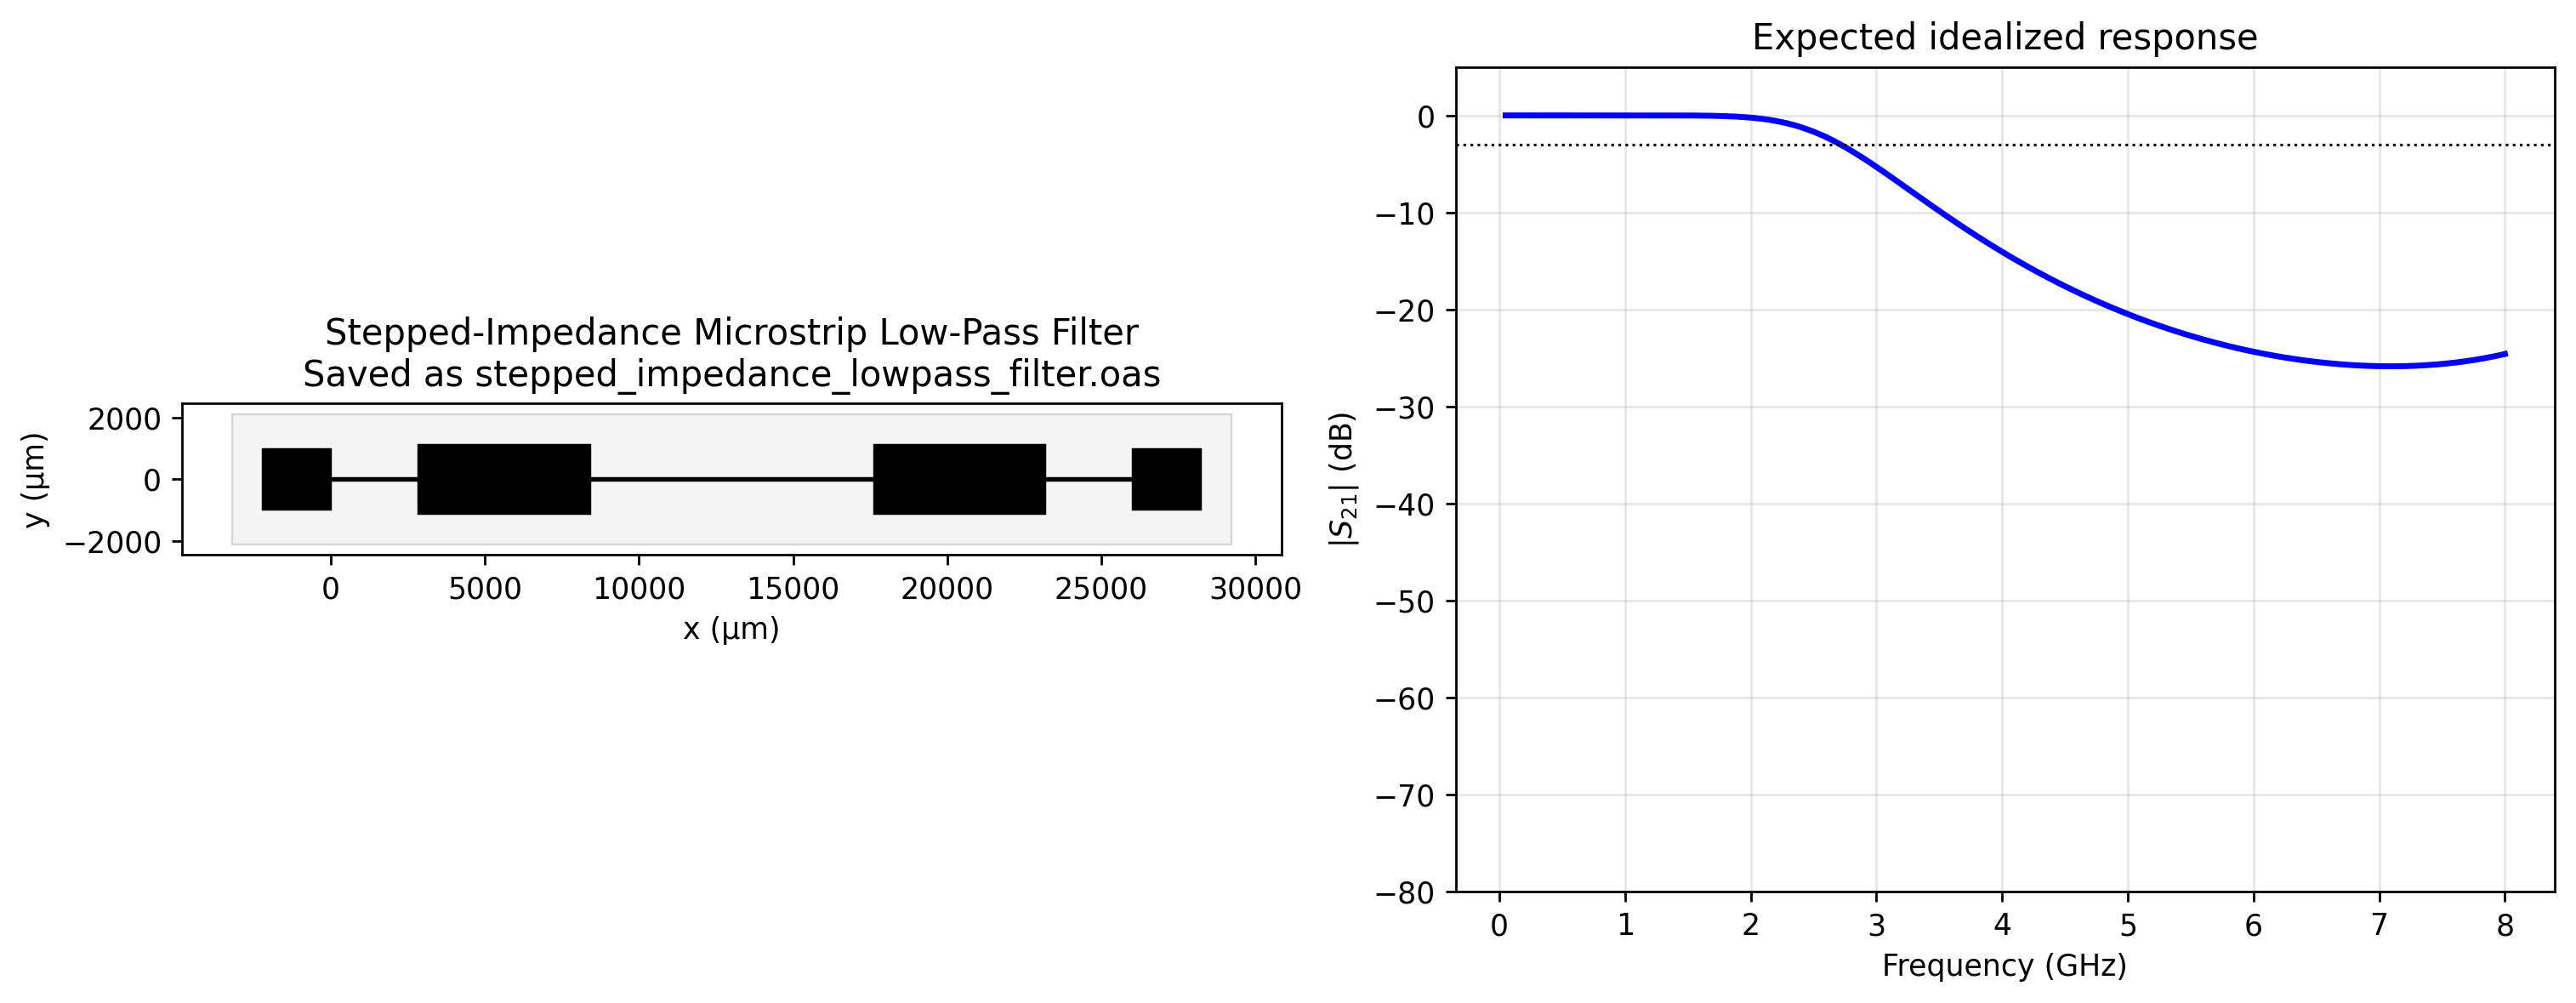

In [3]:
# =============================================================================
# FILTER CELL 1: STEPPED-IMPEDANCE MICROSTRIP LOW-PASS FILTER
# =============================================================================

substrate = SubstrateSpec()
source_z0_ohm = 50.0
high_z0_ohm = 115.0
low_z0_ohm = 18.0
cutoff_ghz = 2.8
filter_order = 5
sweep = SweepSpec(start_ghz=0.05, stop_ghz=8.0, points=1601)

device = Device("stepped_impedance_lowpass_filter")
frequency_ghz = make_frequency_axis(sweep)
prototype_g = butterworth_g_values(filter_order)

x_cursor_um = 0.0
y_center_um = 0.0
main_width_um = width_for_impedance_um(source_z0_ohm, substrate)
section_specs: list[tuple[float, float, float]] = []

for index, g_value in enumerate(prototype_g, start=1):
    if index % 2 == 1:
        section_z0 = high_z0_ohm
        theta_cutoff = g_value * source_z0_ohm / high_z0_ohm
    else:
        section_z0 = low_z0_ohm
        theta_cutoff = g_value * low_z0_ohm / source_z0_ohm

    section_width_um = width_for_impedance_um(section_z0, substrate)
    section_length_um = electrical_length_to_um(
        theta_cutoff,
        cutoff_ghz,
        section_z0,
        substrate,
    )

    add_centered_line(
        device,
        x_cursor_um,
        y_center_um,
        section_length_um,
        section_width_um,
    )
    section_specs.append((section_z0, section_width_um, section_length_um))
    x_cursor_um += section_length_um

add_launch_pads(
    device,
    start_x_um=0.0,
    end_x_um=x_cursor_um,
    y_center_um=y_center_um,
    line_width_um=main_width_um,
)
add_outline(device)

s21_db = stepped_impedance_response_db(
    frequency_ghz=frequency_ghz,
    cutoff_ghz=cutoff_ghz,
    prototype_g=prototype_g,
    source_z0_ohm=source_z0_ohm,
    high_z0_ohm=high_z0_ohm,
    low_z0_ohm=low_z0_ohm,
)

output_path = save_oasis_from_device(device)
report_line_dimensions(substrate, [source_z0_ohm, low_z0_ohm, high_z0_ohm])
print("\nSection summary:")
for section_index, (section_z0, section_width_um, section_length_um) in enumerate(section_specs, start=1):
    print(
        f"{section_index}: Z0 = {section_z0:6.1f} Ω, "
        f"width = {section_width_um:9.2f} µm, "
        f"length = {section_length_um:9.2f} µm"
    )

plot_device_and_response(
    device=device,
    frequency_ghz=frequency_ghz,
    s21_db=s21_db,
    title="Stepped-Impedance Microstrip Low-Pass Filter",
    output_path=output_path,
)


Substrate: Rogers_4350B_10mil
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854
Z0 =   70.0 Ω, width =    308.09 µm, epsilon_eff =  2.733

Quarter-wave main spacing =  18107.44 µm; open-stub length =  18504.49 µm


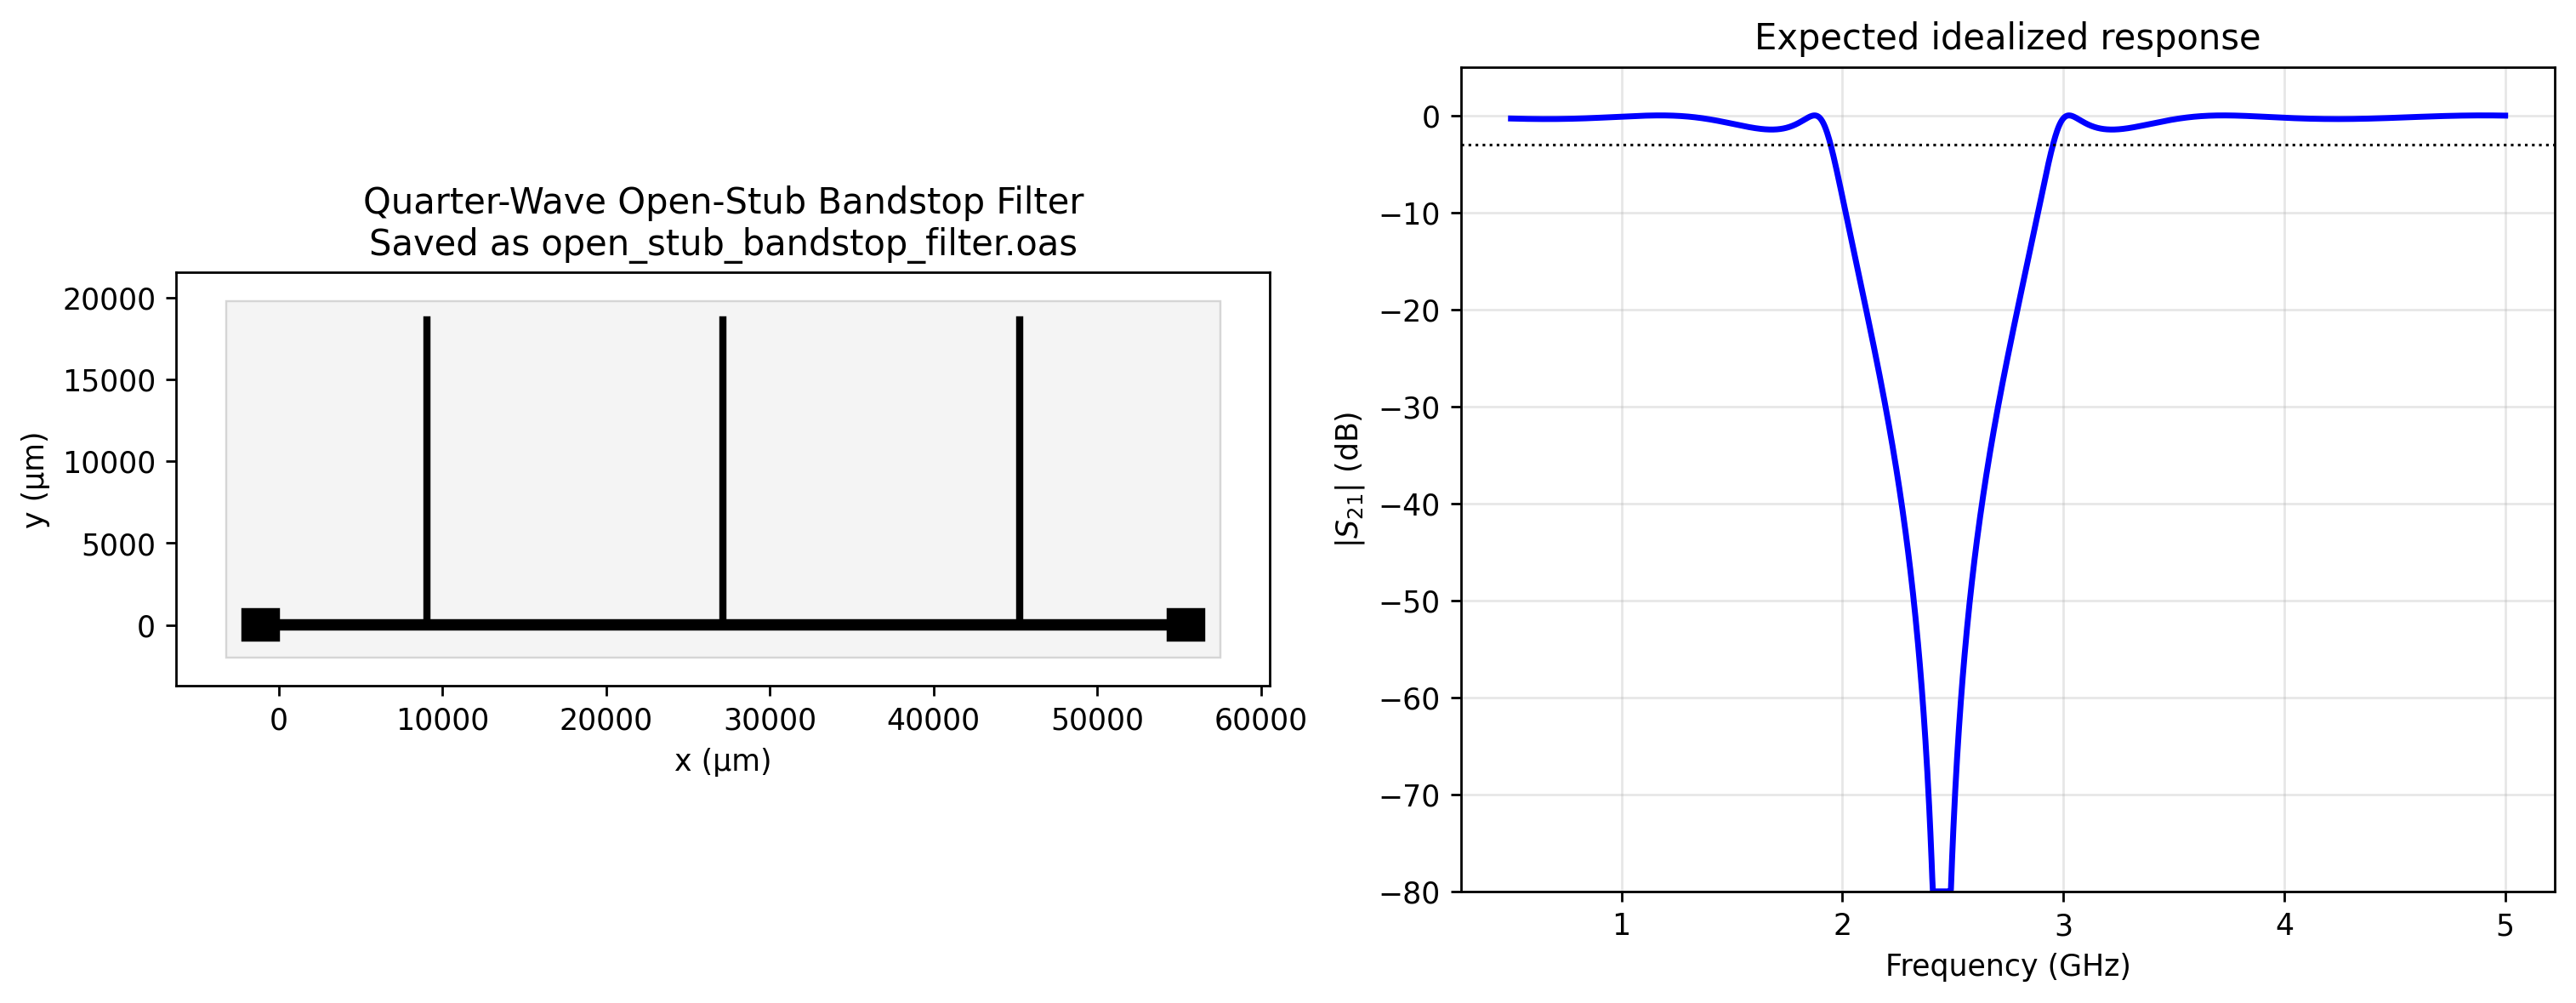

In [4]:
# =============================================================================
# FILTER CELL 2: QUARTER-WAVE OPEN-STUB BANDSTOP FILTER
# =============================================================================

substrate = SubstrateSpec()
center_ghz = 2.45
main_z0_ohm = 50.0
stub_z0_ohm = 70.0
number_of_stubs = 3
sweep = SweepSpec(start_ghz=0.5, stop_ghz=5.0, points=1601)

device = Device("open_stub_bandstop_filter")
frequency_ghz = make_frequency_axis(sweep)

main_width_um = width_for_impedance_um(main_z0_ohm, substrate)
stub_width_um = width_for_impedance_um(stub_z0_ohm, substrate)
quarter_main_um = electrical_length_to_um(0.5 * np.pi, center_ghz, main_z0_ohm, substrate)
quarter_stub_um = electrical_length_to_um(0.5 * np.pi, center_ghz, stub_z0_ohm, substrate)
end_section_um = 0.5 * quarter_main_um

x_start_um = 0.0
x_stop_um = 2.0 * end_section_um + (number_of_stubs - 1) * quarter_main_um
add_centered_line(device, x_start_um, 0.0, x_stop_um, main_width_um)

stub_positions_um = [
    end_section_um + index * quarter_main_um
    for index in range(number_of_stubs)
]

for x_position_um in stub_positions_um:
    add_vertical_line(
        device,
        x_center_um=x_position_um,
        y_um=0.5 * main_width_um,
        length_um=quarter_stub_um,
        width_um=stub_width_um,
    )

add_launch_pads(
    device,
    start_x_um=x_start_um,
    end_x_um=x_stop_um,
    y_center_um=0.0,
    line_width_um=main_width_um,
)
add_outline(device)

s21_db = open_or_short_stub_response_db(
    frequency_ghz=frequency_ghz,
    center_ghz=center_ghz,
    number_of_stubs=number_of_stubs,
    main_z0_ohm=main_z0_ohm,
    stub_z0_ohm=stub_z0_ohm,
    stub_kind="open",
)

output_path = save_oasis_from_device(device)
report_line_dimensions(substrate, [main_z0_ohm, stub_z0_ohm])
print(
    f"\nQuarter-wave main spacing = {quarter_main_um:9.2f} µm; "
    f"open-stub length = {quarter_stub_um:9.2f} µm"
)

plot_device_and_response(
    device=device,
    frequency_ghz=frequency_ghz,
    s21_db=s21_db,
    title="Quarter-Wave Open-Stub Bandstop Filter",
    output_path=output_path,
)


Substrate: Rogers_4350B_10mil
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854
Z0 =   38.0 Ω, width =    848.04 µm, epsilon_eff =  2.951

Quarter-wave main spacing =  18107.44 µm; shorted-stub length =  17809.27 µm


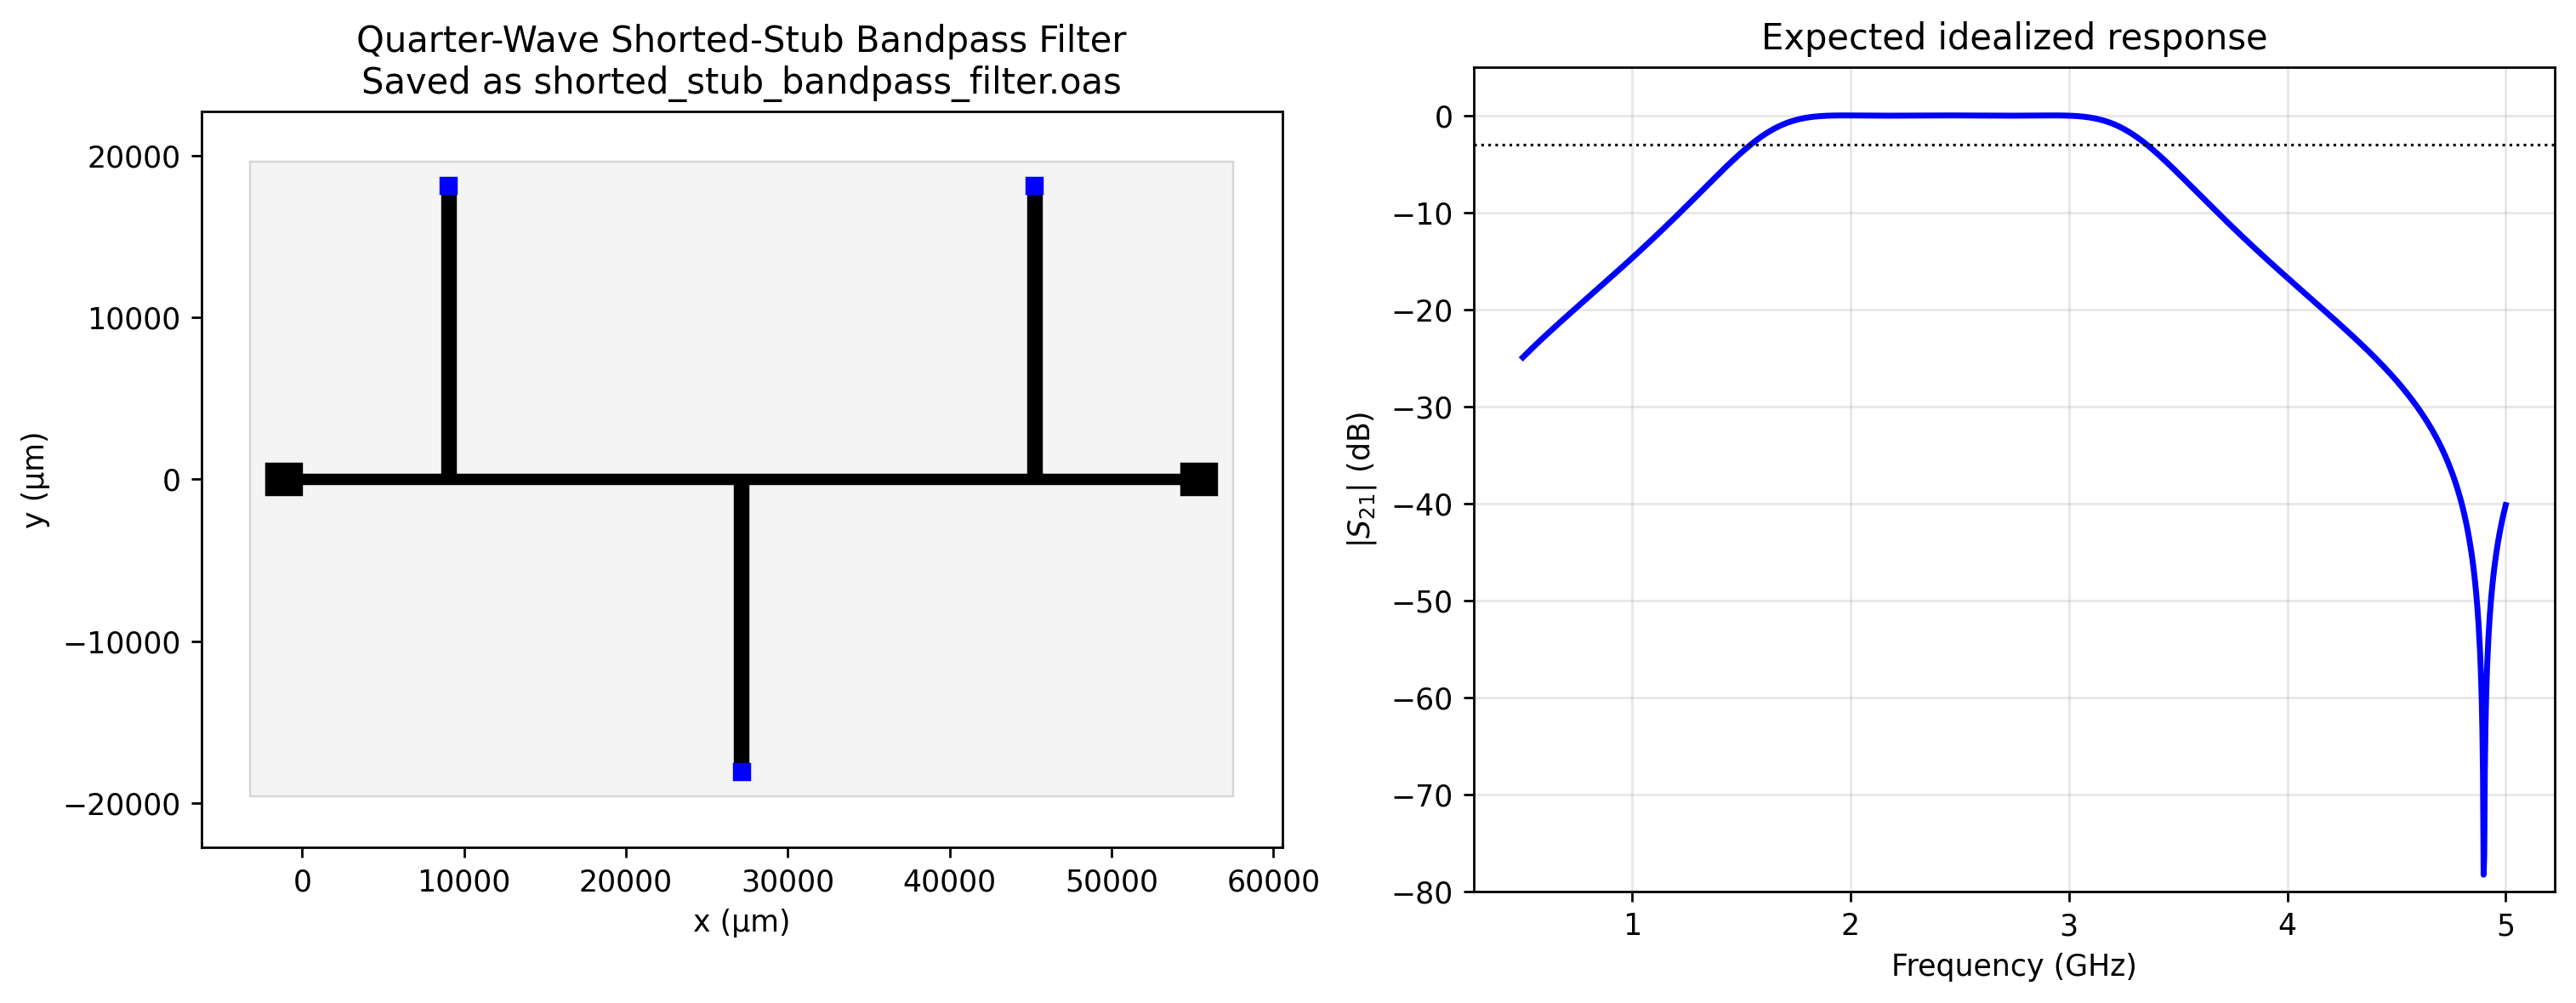

In [5]:
# =============================================================================
# FILTER CELL 3: QUARTER-WAVE SHORTED-STUB BANDPASS FILTER
# =============================================================================

substrate = SubstrateSpec()
center_ghz = 2.45
main_z0_ohm = 50.0
stub_z0_ohm = 38.0
number_of_stubs = 3
via_pad_um = 1_000.0
sweep = SweepSpec(start_ghz=0.5, stop_ghz=5.0, points=1601)

device = Device("shorted_stub_bandpass_filter")
frequency_ghz = make_frequency_axis(sweep)

main_width_um = width_for_impedance_um(main_z0_ohm, substrate)
stub_width_um = width_for_impedance_um(stub_z0_ohm, substrate)
quarter_main_um = electrical_length_to_um(0.5 * np.pi, center_ghz, main_z0_ohm, substrate)
quarter_stub_um = electrical_length_to_um(0.5 * np.pi, center_ghz, stub_z0_ohm, substrate)
end_section_um = 0.5 * quarter_main_um

x_start_um = 0.0
x_stop_um = 2.0 * end_section_um + (number_of_stubs - 1) * quarter_main_um
add_centered_line(device, x_start_um, 0.0, x_stop_um, main_width_um)

stub_positions_um = [
    end_section_um + index * quarter_main_um
    for index in range(number_of_stubs)
]

for index, x_position_um in enumerate(stub_positions_um):
    direction = 1.0 if index % 2 == 0 else -1.0
    y_origin_um = 0.5 * main_width_um if direction > 0.0 else -0.5 * main_width_um - quarter_stub_um

    add_vertical_line(
        device,
        x_center_um=x_position_um,
        y_um=y_origin_um,
        length_um=quarter_stub_um,
        width_um=stub_width_um,
    )

    via_y_um = (
        y_origin_um + quarter_stub_um - 0.5 * via_pad_um
        if direction > 0.0
        else y_origin_um - 0.5 * via_pad_um
    )
    add_rectangle(
        device,
        x_um=x_position_um - 0.5 * via_pad_um,
        y_um=via_y_um,
        width_um=via_pad_um,
        height_um=via_pad_um,
        layer=VIA_LAYER,
    )

add_launch_pads(
    device,
    start_x_um=x_start_um,
    end_x_um=x_stop_um,
    y_center_um=0.0,
    line_width_um=main_width_um,
)
add_outline(device)

s21_db = open_or_short_stub_response_db(
    frequency_ghz=frequency_ghz,
    center_ghz=center_ghz,
    number_of_stubs=number_of_stubs,
    main_z0_ohm=main_z0_ohm,
    stub_z0_ohm=stub_z0_ohm,
    stub_kind="short",
)

output_path = save_oasis_from_device(device)
report_line_dimensions(substrate, [main_z0_ohm, stub_z0_ohm])
print(
    f"\nQuarter-wave main spacing = {quarter_main_um:9.2f} µm; "
    f"shorted-stub length = {quarter_stub_um:9.2f} µm"
)

plot_device_and_response(
    device=device,
    frequency_ghz=frequency_ghz,
    s21_db=s21_db,
    title="Quarter-Wave Shorted-Stub Bandpass Filter",
    output_path=output_path,
)


Substrate: Rogers_4350B_10mil
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854

Quarter-wave section length =  14787.75 µm; edge gap =     88.90 µm


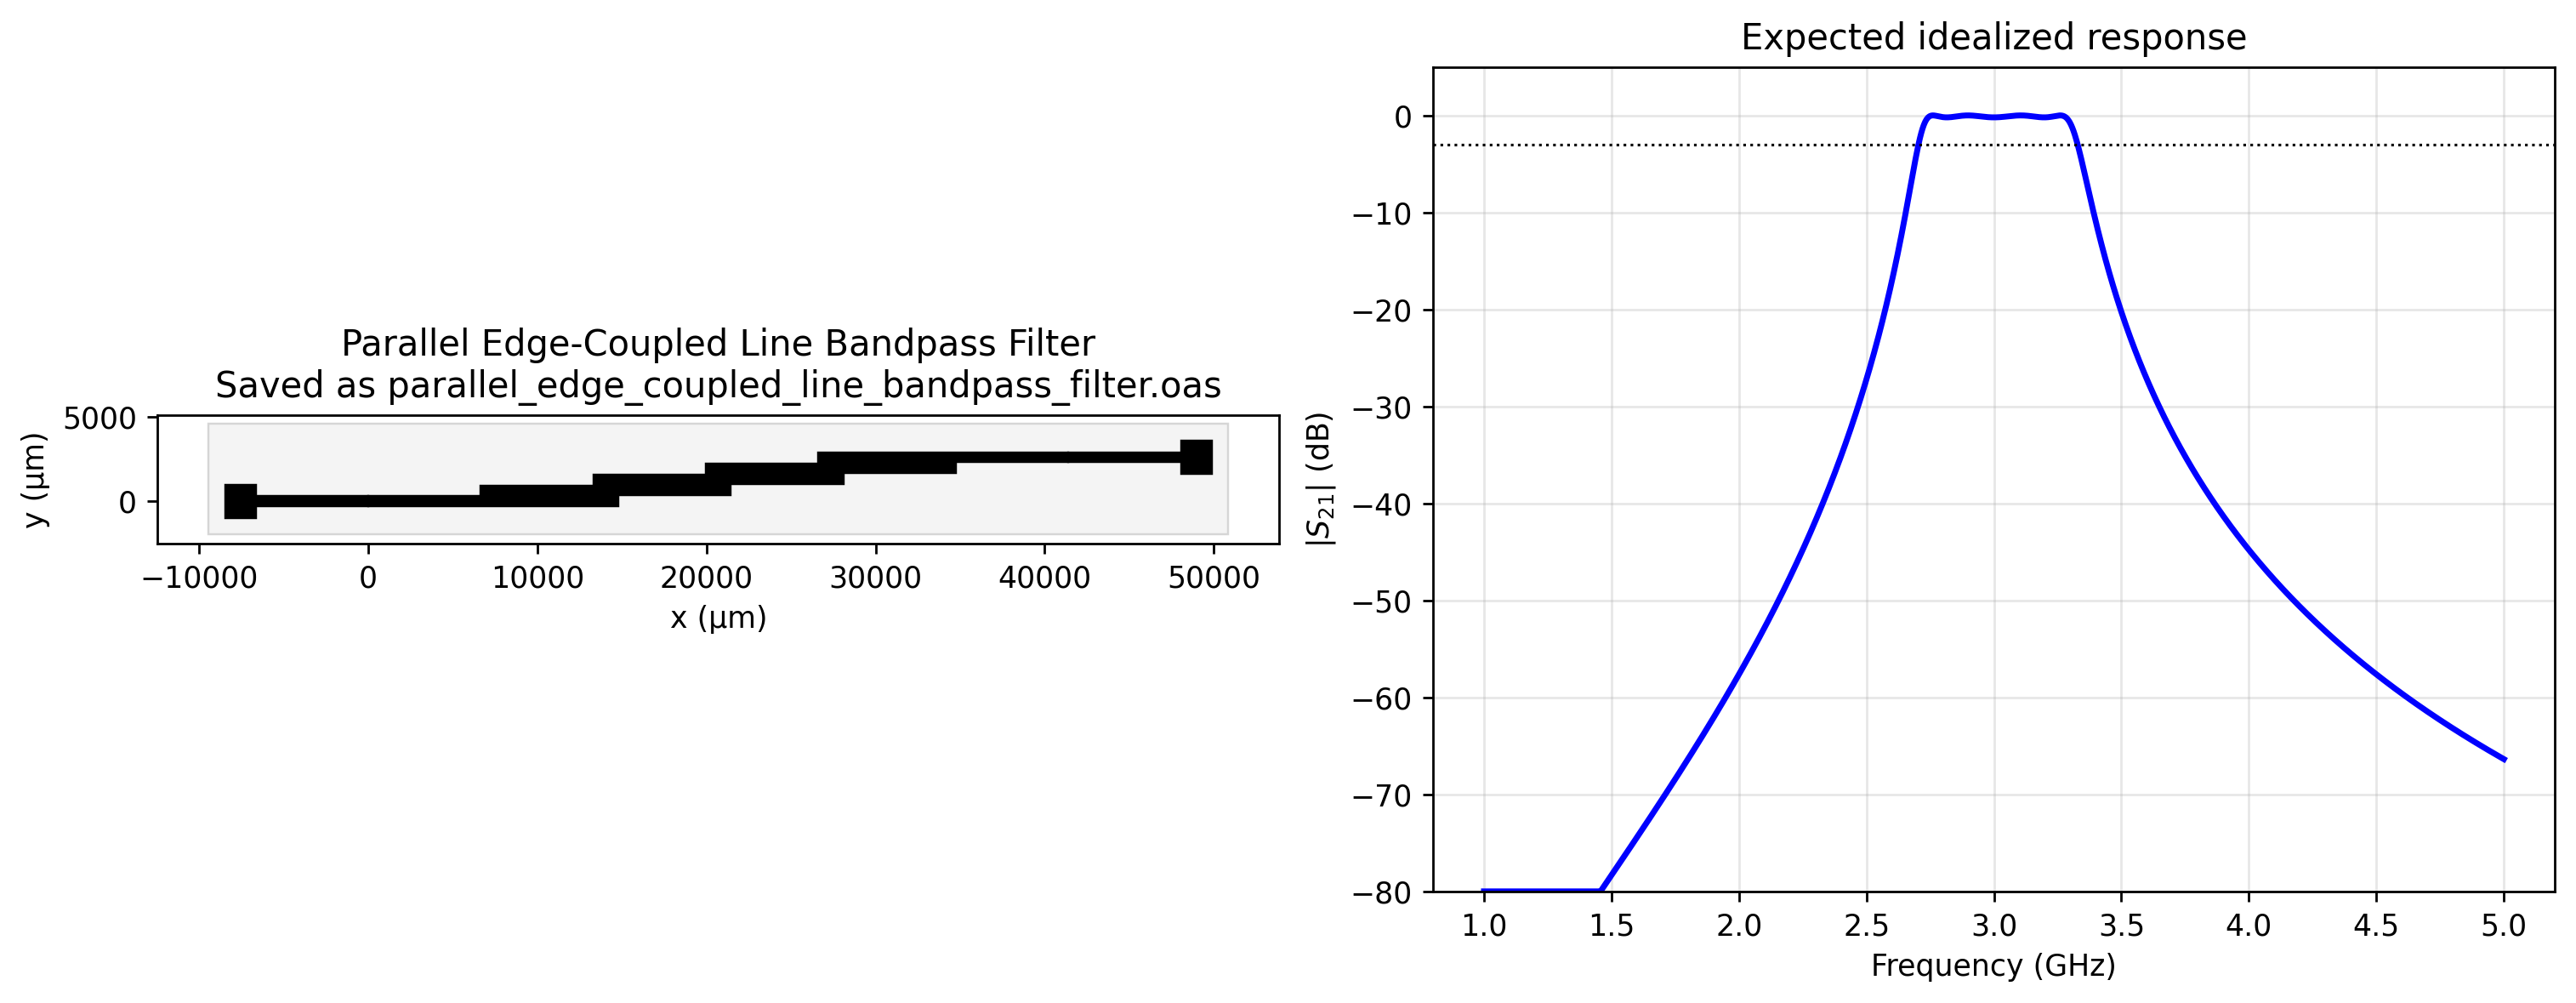

In [6]:
# =============================================================================
# FILTER CELL 4: PARALLEL EDGE-COUPLED LINE BANDPASS FILTER
# =============================================================================

substrate = SubstrateSpec()
center_ghz = 3.0
fractional_bandwidth = 0.18
filter_order = 4
ripple_db = 0.2
line_z0_ohm = 50.0
section_count = filter_order + 1
sweep = SweepSpec(start_ghz=1.0, stop_ghz=5.0, points=1601)

device = Device("parallel_edge_coupled_line_bandpass_filter")
frequency_ghz = make_frequency_axis(sweep)

line_width_um = width_for_impedance_um(line_z0_ohm, substrate)
quarter_wave_um = electrical_length_to_um(0.5 * np.pi, center_ghz, line_z0_ohm, substrate)
gap_um = 0.35 * substrate.thickness_um
x_step_um = 0.45 * quarter_wave_um
feed_length_um = 0.45 * quarter_wave_um

section_y_values_um = [
    index * (line_width_um + gap_um)
    for index in range(section_count)
]

for index, y_center_um in enumerate(section_y_values_um):
    x_position_um = index * x_step_um
    add_centered_line(
        device,
        x_um=x_position_um,
        y_center_um=y_center_um,
        length_um=quarter_wave_um,
        width_um=line_width_um,
    )

input_y_um = section_y_values_um[0]
output_y_um = section_y_values_um[-1]
input_x_um = 0.0
output_x_um = (section_count - 1) * x_step_um + quarter_wave_um

add_centered_line(
    device,
    x_um=input_x_um - feed_length_um,
    y_center_um=input_y_um,
    length_um=feed_length_um,
    width_um=line_width_um,
)
add_centered_line(
    device,
    x_um=output_x_um,
    y_center_um=output_y_um,
    length_um=feed_length_um,
    width_um=line_width_um,
)

add_rectangle(
    device,
    x_um=input_x_um - feed_length_um - 1800.0,
    y_um=input_y_um - 1.75 * line_width_um,
    width_um=1800.0,
    height_um=3.5 * line_width_um,
)
add_rectangle(
    device,
    x_um=output_x_um + feed_length_um,
    y_um=output_y_um - 1.75 * line_width_um,
    width_um=1800.0,
    height_um=3.5 * line_width_um,
)
add_outline(device)

s21_db = chebyshev_bandpass_response_db(
    frequency_ghz=frequency_ghz,
    center_ghz=center_ghz,
    fractional_bandwidth=fractional_bandwidth,
    order=filter_order,
    ripple_db=ripple_db,
)

output_path = save_oasis_from_device(device)
report_line_dimensions(substrate, [line_z0_ohm])
print(
    f"\nQuarter-wave section length = {quarter_wave_um:9.2f} µm; "
    f"edge gap = {gap_um:9.2f} µm"
)

plot_device_and_response(
    device=device,
    frequency_ghz=frequency_ghz,
    s21_db=s21_db,
    title="Parallel Edge-Coupled Line Bandpass Filter",
    output_path=output_path,
)


Substrate: Rogers_4350B_10mil
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854

Half-wave centerline target =  29575.49 µm; arm separation =   1270.00 µm; arm length =  14152.75 µm


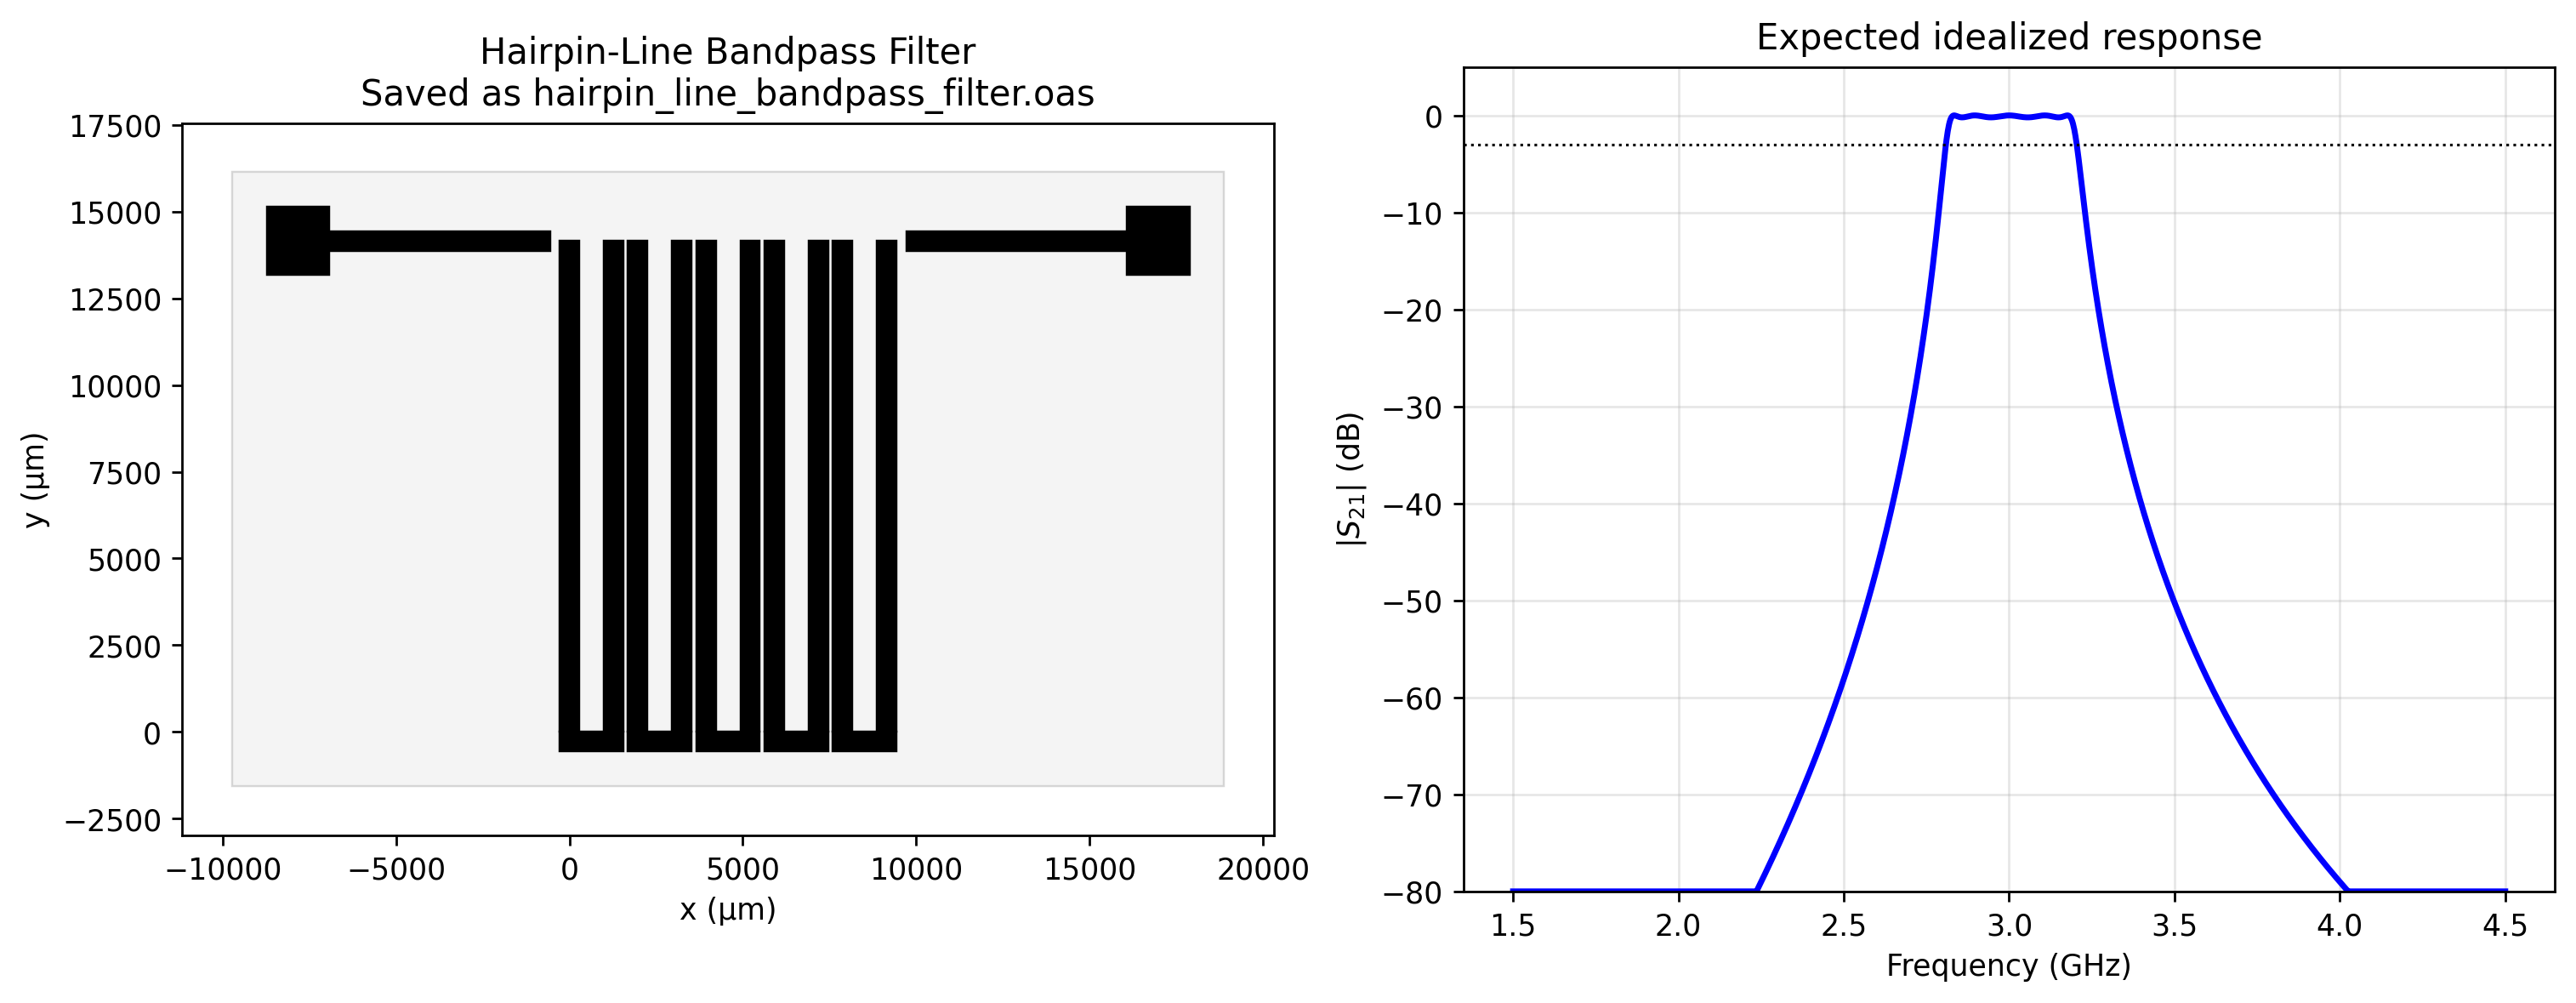

In [7]:
# =============================================================================
# FILTER CELL 5: HAIRPIN-LINE BANDPASS FILTER
# =============================================================================

substrate = SubstrateSpec()
center_ghz = 3.0
fractional_bandwidth = 0.12
filter_order = 5
ripple_db = 0.2
line_z0_ohm = 50.0
resonator_gap_um = 0.55 * substrate.thickness_um
arm_separation_um = 5.0 * substrate.thickness_um
sweep = SweepSpec(start_ghz=1.5, stop_ghz=4.5, points=1601)

device = Device("hairpin_line_bandpass_filter")
frequency_ghz = make_frequency_axis(sweep)

line_width_um = width_for_impedance_um(line_z0_ohm, substrate)
lambda_g_um = guided_wavelength_um(center_ghz, line_z0_ohm, substrate)
half_wave_um = 0.5 * lambda_g_um
arm_length_um = 0.5 * (half_wave_um - arm_separation_um)
pitch_um = arm_separation_um + line_width_um + resonator_gap_um

def add_hairpin(
    target: Device,
    x_origin_um: float,
    y_origin_um: float,
    arm_length_value_um: float,
    arm_separation_value_um: float,
    trace_width_um: float,
) -> None:
    """Add a U-shaped half-wave hairpin resonator."""

    add_vertical_line(
        target,
        x_center_um=x_origin_um,
        y_um=y_origin_um,
        length_um=arm_length_value_um,
        width_um=trace_width_um,
    )
    add_vertical_line(
        target,
        x_center_um=x_origin_um + arm_separation_value_um,
        y_um=y_origin_um,
        length_um=arm_length_value_um,
        width_um=trace_width_um,
    )
    add_rectangle(
        target,
        x_um=x_origin_um - 0.5 * trace_width_um,
        y_um=y_origin_um - trace_width_um,
        width_um=arm_separation_value_um + trace_width_um,
        height_um=trace_width_um,
    )

for index in range(filter_order):
    add_hairpin(
        target=device,
        x_origin_um=index * pitch_um,
        y_origin_um=0.0,
        arm_length_value_um=arm_length_um,
        arm_separation_value_um=arm_separation_um,
        trace_width_um=line_width_um,
    )

feed_length_um = 0.45 * arm_length_um
input_x_um = -feed_length_um - line_width_um
output_x_um = (filter_order - 1) * pitch_um + arm_separation_um + line_width_um

add_centered_line(
    device,
    x_um=input_x_um,
    y_center_um=arm_length_um,
    length_um=feed_length_um,
    width_um=line_width_um,
)
add_centered_line(
    device,
    x_um=output_x_um,
    y_center_um=arm_length_um,
    length_um=feed_length_um,
    width_um=line_width_um,
)
add_rectangle(
    device,
    x_um=input_x_um - 1800.0,
    y_um=arm_length_um - 1.75 * line_width_um,
    width_um=1800.0,
    height_um=3.5 * line_width_um,
)
add_rectangle(
    device,
    x_um=output_x_um + feed_length_um,
    y_um=arm_length_um - 1.75 * line_width_um,
    width_um=1800.0,
    height_um=3.5 * line_width_um,
)
add_outline(device)

s21_db = chebyshev_bandpass_response_db(
    frequency_ghz=frequency_ghz,
    center_ghz=center_ghz,
    fractional_bandwidth=fractional_bandwidth,
    order=filter_order,
    ripple_db=ripple_db,
)

output_path = save_oasis_from_device(device)
report_line_dimensions(substrate, [line_z0_ohm])
print(
    f"\nHalf-wave centerline target = {half_wave_um:9.2f} µm; "
    f"arm separation = {arm_separation_um:9.2f} µm; "
    f"arm length = {arm_length_um:9.2f} µm"
)

plot_device_and_response(
    device=device,
    frequency_ghz=frequency_ghz,
    s21_db=s21_db,
    title="Hairpin-Line Bandpass Filter",
    output_path=output_path,
)


Substrate: Rogers_4350B_10mil
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854
Z0 =   50.0 Ω, width =    560.41 µm, epsilon_eff =  2.854

Quarter-wave shunt resonator length =  17745.30 µm; series coupling gap =     85.00 µm


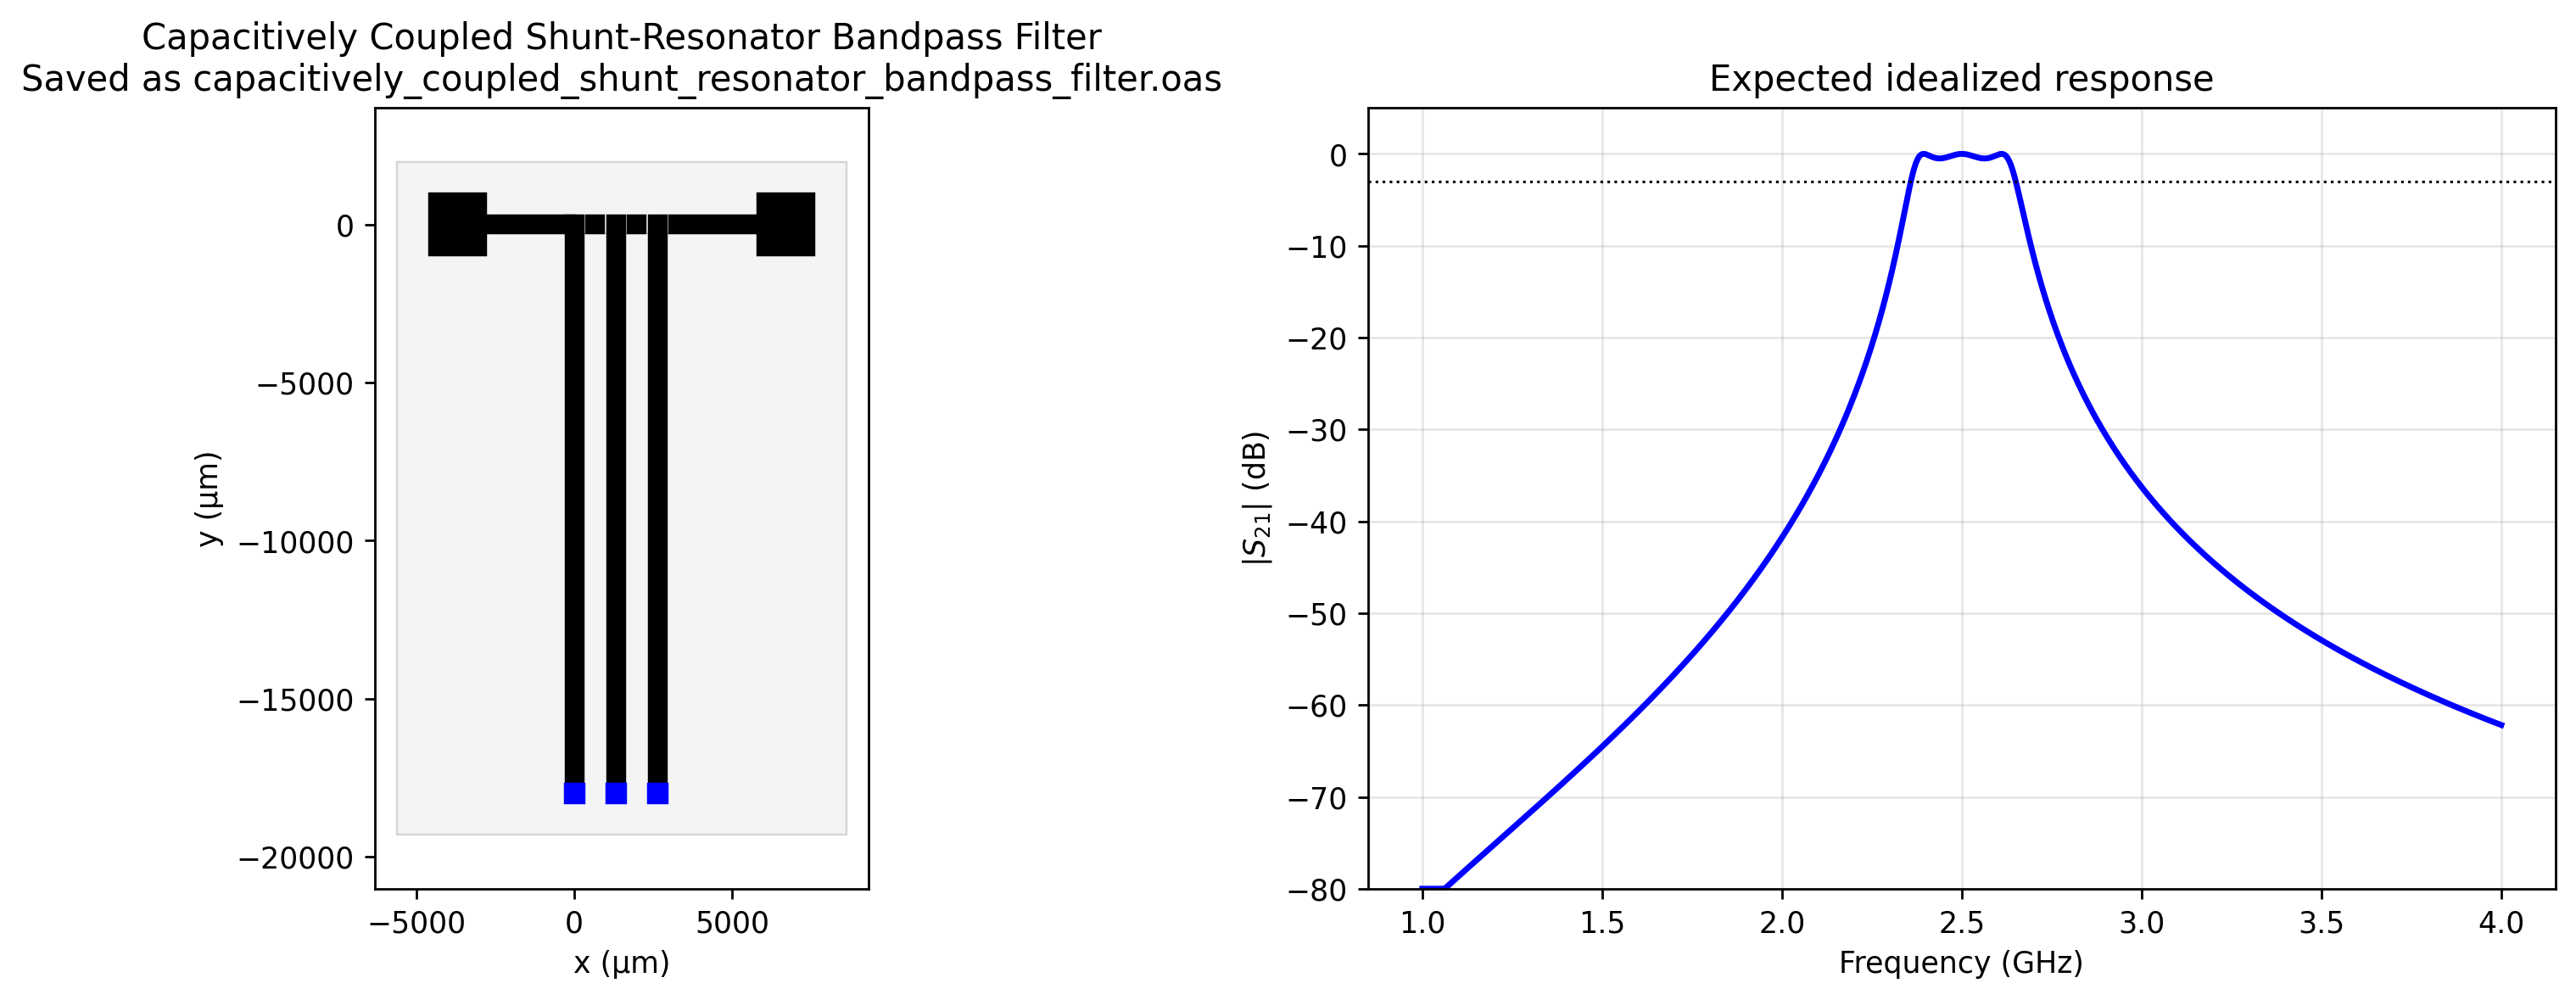

In [8]:
# =============================================================================
# FILTER CELL 6: CAPACITIVELY COUPLED SHUNT-RESONATOR BANDPASS FILTER
# =============================================================================

substrate = SubstrateSpec()
center_ghz = 2.5
fractional_bandwidth = 0.10
filter_order = 3
ripple_db = 0.5
line_z0_ohm = 50.0
resonator_z0_ohm = 50.0
series_gap_um = 85.0
sweep = SweepSpec(start_ghz=1.0, stop_ghz=4.0, points=1601)

device = Device("capacitively_coupled_shunt_resonator_bandpass_filter")
frequency_ghz = make_frequency_axis(sweep)

line_width_um = width_for_impedance_um(line_z0_ohm, substrate)
resonator_width_um = width_for_impedance_um(resonator_z0_ohm, substrate)
quarter_resonator_um = electrical_length_to_um(
    0.5 * np.pi,
    center_ghz,
    resonator_z0_ohm,
    substrate,
)
section_pitch_um = 2.2 * line_width_um + series_gap_um

x_cursor_um = 0.0
feed_length_um = 2800.0
add_centered_line(device, x_cursor_um - feed_length_um, 0.0, feed_length_um, line_width_um)

for index in range(filter_order):
    x_center_um = x_cursor_um + index * section_pitch_um

    add_centered_line(
        device,
        x_um=x_center_um - 0.5 * line_width_um,
        y_center_um=0.0,
        length_um=line_width_um,
        width_um=line_width_um,
    )
    add_vertical_line(
        device,
        x_center_um=x_center_um,
        y_um=-quarter_resonator_um - 0.5 * line_width_um,
        length_um=quarter_resonator_um,
        width_um=resonator_width_um,
    )
    add_rectangle(
        device,
        x_um=x_center_um - 0.55 * line_width_um,
        y_um=-quarter_resonator_um - line_width_um,
        width_um=1.1 * line_width_um,
        height_um=1.1 * line_width_um,
        layer=VIA_LAYER,
    )

    if index < filter_order - 1:
        add_centered_line(
            device,
            x_um=x_center_um + 0.5 * line_width_um + series_gap_um,
            y_center_um=0.0,
            length_um=line_width_um,
            width_um=line_width_um,
        )

x_last_um = (filter_order - 1) * section_pitch_um
add_centered_line(
    device,
    x_um=x_last_um + 0.5 * line_width_um + series_gap_um,
    y_center_um=0.0,
    length_um=feed_length_um,
    width_um=line_width_um,
)
add_rectangle(
    device,
    x_um=-feed_length_um - 1800.0,
    y_um=-1.75 * line_width_um,
    width_um=1800.0,
    height_um=3.5 * line_width_um,
)
add_rectangle(
    device,
    x_um=x_last_um + 0.5 * line_width_um + series_gap_um + feed_length_um,
    y_um=-1.75 * line_width_um,
    width_um=1800.0,
    height_um=3.5 * line_width_um,
)
add_outline(device)

s21_db = chebyshev_bandpass_response_db(
    frequency_ghz=frequency_ghz,
    center_ghz=center_ghz,
    fractional_bandwidth=fractional_bandwidth,
    order=filter_order,
    ripple_db=ripple_db,
)

output_path = save_oasis_from_device(device)
report_line_dimensions(substrate, [line_z0_ohm, resonator_z0_ohm])
print(
    f"\nQuarter-wave shunt resonator length = {quarter_resonator_um:9.2f} µm; "
    f"series coupling gap = {series_gap_um:9.2f} µm"
)

plot_device_and_response(
    device=device,
    frequency_ghz=frequency_ghz,
    s21_db=s21_db,
    title="Capacitively Coupled Shunt-Resonator Bandpass Filter",
    output_path=output_path,
)


Interdigitated microstrip bandpass filter generated.
OASIS file: oas_filter_layouts/interdigitated_microstrip_bandpass_filter.oas
Key layout parameters:
  feed_width_um: 1185.8989
  resonator_width_um: 659.7761
  epsilon_eff: 2.5619
  quarter_wave_um: 9365.0687
  resonator_length_um: 8990.4659
  coupling_gap_um: 95.0000
  filter_width_um: 3678.8804


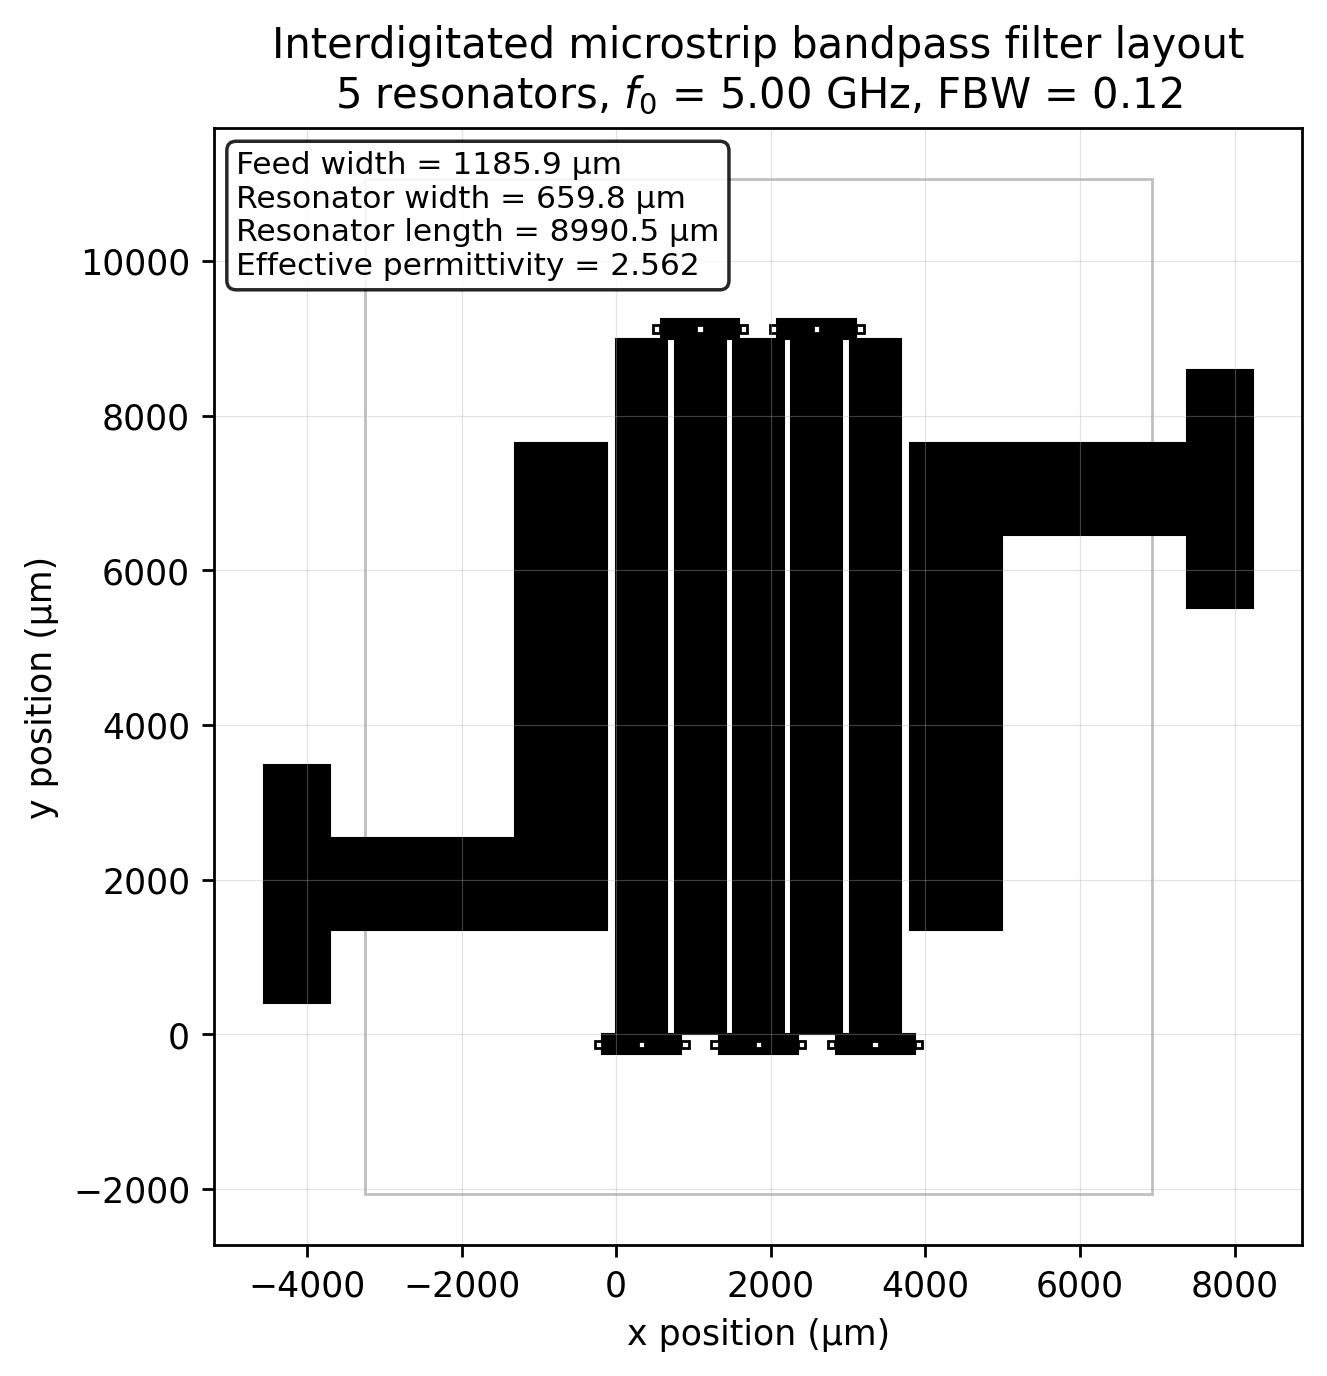

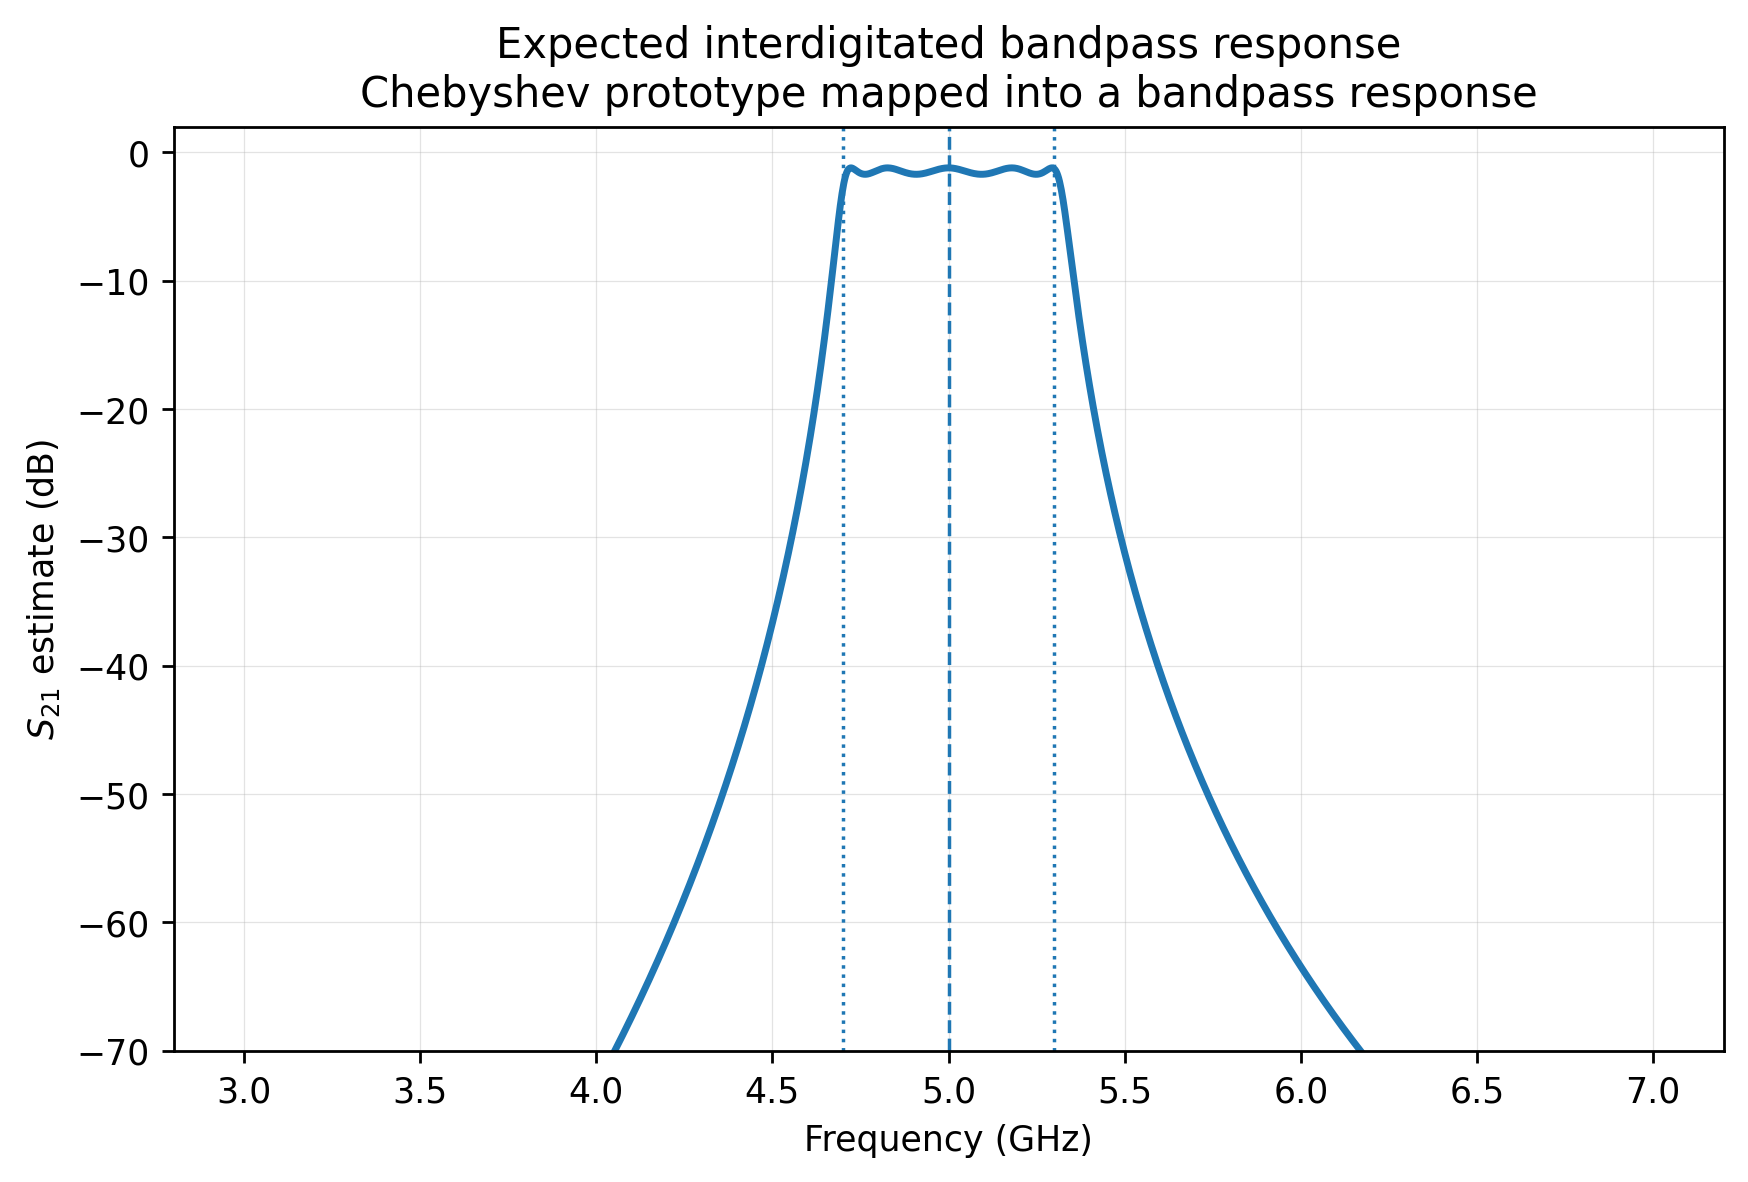

In [9]:
"""Interdigitated microstrip bandpass filter layout and response estimate."""

# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import phidl.geometry as pg
from matplotlib.patches import Polygon
from phidl import Device

# =============================================================================
# CONTROL KNOBS
# =============================================================================

FILTER_NAME = "interdigitated_microstrip_bandpass_filter"
OASIS_DIRECTORY = Path("oas_filter_layouts")

MPL_DPI = 250
LAYOUT_FIGURE_SIZE_IN = (9.0, 5.8)
RESPONSE_FIGURE_SIZE_IN = (8.0, 4.8)

METAL_LAYER = 1
VIA_LAYER = 2
BOUNDARY_LAYER = 10

ORDER = 5
CENTER_FREQUENCY_GHZ = 5.0
FRACTIONAL_BANDWIDTH = 0.12
RIPPLE_DB = 0.5
PASSBAND_INSERTION_LOSS_DB = 1.2

Z0_OHM = 50.0
RESONATOR_Z0_OHM = 70.0
EPSILON_R = 3.38
SUBSTRATE_HEIGHT_UM = 508.0
ELECTRICAL_LENGTH_SCALE = 0.96

COUPLING_GAP_UM = 95.0
INPUT_OUTPUT_GAP_UM = 120.0
SHORT_PAD_OVERHANG_UM = 180.0
SHORT_PAD_HEIGHT_UM = 260.0
VIA_PAD_SIZE_UM = 95.0
VIA_PITCH_UM = 260.0

FEED_EXTENSION_UM = 2400.0
FEED_COUPLING_LENGTH_FRACTION = 0.70
PORT_PAD_LENGTH_UM = 850.0
PORT_PAD_WIDTH_FACTOR = 2.6

FREQUENCY_MIN_GHZ = 3.0
FREQUENCY_MAX_GHZ = 7.0
FREQUENCY_POINTS = 1601

mpl.rcParams["figure.dpi"] = MPL_DPI


# =============================================================================
# MICROSTRIP AND FILTER HELPERS
# =============================================================================

def microstrip_effective_epsilon(width_um, height_um, epsilon_r):
    """Return the quasi-static effective permittivity of a microstrip."""
    width_height_ratio = width_um / height_um
    correction = 1.0 / np.sqrt(1.0 + 12.0 / width_height_ratio)
    return 0.5 * (epsilon_r + 1.0) + 0.5 * (epsilon_r - 1.0) * correction


def microstrip_z0(width_um, height_um, epsilon_r):
    """Return the Hammerstad-style quasi-static microstrip impedance."""
    width_height_ratio = width_um / height_um
    epsilon_eff = microstrip_effective_epsilon(
        width_um,
        height_um,
        epsilon_r,
    )

    if width_height_ratio <= 1.0:
        argument = 8.0 / width_height_ratio + 0.25 * width_height_ratio
        return 60.0 * np.log(argument) / np.sqrt(epsilon_eff)

    denominator = (
        width_height_ratio
        + 1.393
        + 0.667 * np.log(width_height_ratio + 1.444)
    )
    return 120.0 * np.pi / (np.sqrt(epsilon_eff) * denominator)


def solve_microstrip_width(target_z0_ohm, height_um, epsilon_r):
    """Solve for the microstrip width that gives the target impedance."""
    lower_um = 0.02 * height_um
    upper_um = 20.0 * height_um

    for _ in range(80):
        middle_um = 0.5 * (lower_um + upper_um)
        trial_z0 = microstrip_z0(middle_um, height_um, epsilon_r)

        if trial_z0 > target_z0_ohm:
            lower_um = middle_um
        else:
            upper_um = middle_um

    return 0.5 * (lower_um + upper_um)


def guided_quarter_wavelength_um(frequency_ghz, epsilon_eff):
    """Return the guided quarter wavelength in micrometers."""
    c_um_per_s = 2.99792458e14
    frequency_hz = frequency_ghz * 1.0e9
    wavelength_um = c_um_per_s / (frequency_hz * np.sqrt(epsilon_eff))
    return wavelength_um / 4.0


def add_rectangle(device, origin_um, size_um, layer):
    """Add a rectangular PHIDL polygon reference to a device."""
    rectangle = pg.rectangle(size=size_um, layer=layer)
    reference = device.add_ref(rectangle)
    reference.move(origin_um)
    return reference


def add_via_pad(device, center_um, size_um, layer):
    """Add a square via pad centered at the requested coordinate."""
    origin_um = (
        center_um[0] - 0.5 * size_um,
        center_um[1] - 0.5 * size_um,
    )
    return add_rectangle(device, origin_um, (size_um, size_um), layer)


def sanitize_cell_name(name):
    """Return a GDSTK-safe cell name."""
    cleaned = []
    for character in name:
        if character.isalnum():
            cleaned.append(character.upper())
        else:
            cleaned.append("_")

    cell_name = "".join(cleaned).strip("_")
    if len(cell_name) == 0:
        cell_name = "FILTER"

    return cell_name[:64]


def write_device_to_oasis(device, file_path, cell_name):
    """Write PHIDL polygons into an OASIS file through GDSTK."""
    library = gdstk.Library(unit=1.0e-6, precision=1.0e-9)
    cell = library.new_cell(cell_name)

    polygons_by_spec = device.get_polygons(by_spec=True)

    for layer_spec, polygons in polygons_by_spec.items():
        if isinstance(layer_spec, tuple):
            layer, data_type = layer_spec
        else:
            layer = int(layer_spec)
            data_type = 0

        for polygon_points in polygons:
            cell.add(
                gdstk.Polygon(
                    polygon_points,
                    layer=int(layer),
                    datatype=int(data_type),
                )
            )

    file_path.parent.mkdir(parents=True, exist_ok=True)
    library.write_oas(str(file_path))


def chebyshev_t(order, x_values):
    """Evaluate the Chebyshev polynomial with stable real branches."""
    x_values = np.asarray(x_values, dtype=np.float64)
    result = np.empty_like(x_values)

    in_band = np.abs(x_values) <= 1.0
    out_band = np.logical_not(in_band)

    result[in_band] = np.cos(order * np.arccos(x_values[in_band]))

    abs_x = np.abs(x_values[out_band])
    sign = np.sign(x_values[out_band]) ** order
    result[out_band] = sign * np.cosh(order * np.arccosh(abs_x))

    return result


def expected_bandpass_response_db(
    frequency_ghz,
    center_frequency_ghz,
    fractional_bandwidth,
    order,
    ripple_db,
    insertion_loss_db,
):
    """Return a synthesis-level Chebyshev bandpass S21 estimate in dB."""
    epsilon = np.sqrt(10.0 ** (ripple_db / 10.0) - 1.0)
    mapped_frequency = (
        frequency_ghz / center_frequency_ghz
        - center_frequency_ghz / frequency_ghz
    ) / fractional_bandwidth

    chebyshev_value = chebyshev_t(order, mapped_frequency)
    magnitude = 1.0 / np.sqrt(1.0 + epsilon**2 * chebyshev_value**2)
    s21_db = 20.0 * np.log10(np.maximum(magnitude, 1.0e-10))
    return np.maximum(s21_db - insertion_loss_db, -90.0)


# =============================================================================
# INTERDIGITATED FILTER LAYOUT
# =============================================================================

def build_interdigitated_filter():
    """Build an interdigitated microstrip bandpass filter PHIDL device."""
    if ORDER < 3:
        raise ValueError("ORDER must be at least 3.")
    if ORDER % 2 == 0:
        raise ValueError("ORDER should be odd for the symmetric default layout.")

    feed_width_um = solve_microstrip_width(
        Z0_OHM,
        SUBSTRATE_HEIGHT_UM,
        EPSILON_R,
    )
    resonator_width_um = solve_microstrip_width(
        RESONATOR_Z0_OHM,
        SUBSTRATE_HEIGHT_UM,
        EPSILON_R,
    )
    epsilon_eff = microstrip_effective_epsilon(
        resonator_width_um,
        SUBSTRATE_HEIGHT_UM,
        EPSILON_R,
    )
    quarter_wave_um = guided_quarter_wavelength_um(
        CENTER_FREQUENCY_GHZ,
        epsilon_eff,
    )
    resonator_length_um = ELECTRICAL_LENGTH_SCALE * quarter_wave_um

    pitch_um = resonator_width_um + COUPLING_GAP_UM
    resonator_x_um = np.arange(ORDER, dtype=np.float64) * pitch_um

    filter_width_um = resonator_x_um[-1] + resonator_width_um
    feed_coupling_length_um = (
        FEED_COUPLING_LENGTH_FRACTION * resonator_length_um
    )

    input_coupler_x_um = -INPUT_OUTPUT_GAP_UM - feed_width_um
    output_coupler_x_um = filter_width_um + INPUT_OUTPUT_GAP_UM

    device = Device(FILTER_NAME)

    add_rectangle(
        device,
        (
            -FEED_EXTENSION_UM - PORT_PAD_LENGTH_UM,
            -0.23 * resonator_length_um,
        ),
        (
            filter_width_um
            + 2.0 * FEED_EXTENSION_UM
            + 2.0 * PORT_PAD_LENGTH_UM,
            1.46 * resonator_length_um,
        ),
        BOUNDARY_LAYER,
    )

    for index, x_um in enumerate(resonator_x_um):
        add_rectangle(
            device,
            (x_um, 0.0),
            (resonator_width_um, resonator_length_um),
            METAL_LAYER,
        )

        short_at_bottom = index % 2 == 0

        if short_at_bottom:
            short_y_um = -SHORT_PAD_HEIGHT_UM
            via_y_um = -0.5 * SHORT_PAD_HEIGHT_UM
        else:
            short_y_um = resonator_length_um
            via_y_um = resonator_length_um + 0.5 * SHORT_PAD_HEIGHT_UM

        add_rectangle(
            device,
            (
                x_um - SHORT_PAD_OVERHANG_UM,
                short_y_um,
            ),
            (
                resonator_width_um + 2.0 * SHORT_PAD_OVERHANG_UM,
                SHORT_PAD_HEIGHT_UM,
            ),
            METAL_LAYER,
        )

        via_count = max(
            1,
            int(
                np.floor(
                    (
                        resonator_width_um
                        + 2.0 * SHORT_PAD_OVERHANG_UM
                    )
                    / VIA_PITCH_UM
                )
            ),
        )
        via_offsets = np.linspace(
            -0.35 * resonator_width_um,
            1.35 * resonator_width_um,
            via_count,
        )

        for offset_um in via_offsets:
            add_via_pad(
                device,
                (x_um + offset_um, via_y_um),
                VIA_PAD_SIZE_UM,
                VIA_LAYER,
            )

    input_coupler_y_um = 0.15 * resonator_length_um
    output_coupler_y_um = (
        resonator_length_um
        - input_coupler_y_um
        - feed_coupling_length_um
    )

    add_rectangle(
        device,
        (input_coupler_x_um, input_coupler_y_um),
        (feed_width_um, feed_coupling_length_um),
        METAL_LAYER,
    )
    add_rectangle(
        device,
        (
            input_coupler_x_um - FEED_EXTENSION_UM,
            input_coupler_y_um,
        ),
        (FEED_EXTENSION_UM, feed_width_um),
        METAL_LAYER,
    )
    add_rectangle(
        device,
        (
            input_coupler_x_um - FEED_EXTENSION_UM - PORT_PAD_LENGTH_UM,
            input_coupler_y_um
            - 0.5 * feed_width_um * (PORT_PAD_WIDTH_FACTOR - 1.0),
        ),
        (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        METAL_LAYER,
    )

    add_rectangle(
        device,
        (output_coupler_x_um, output_coupler_y_um),
        (feed_width_um, feed_coupling_length_um),
        METAL_LAYER,
    )
    add_rectangle(
        device,
        (
            output_coupler_x_um + feed_width_um,
            output_coupler_y_um + feed_coupling_length_um - feed_width_um,
        ),
        (FEED_EXTENSION_UM, feed_width_um),
        METAL_LAYER,
    )
    add_rectangle(
        device,
        (
            output_coupler_x_um
            + feed_width_um
            + FEED_EXTENSION_UM,
            output_coupler_y_um
            + feed_coupling_length_um
            - 0.5 * feed_width_um * (PORT_PAD_WIDTH_FACTOR + 1.0),
        ),
        (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        METAL_LAYER,
    )

    parameters = {
        "feed_width_um": feed_width_um,
        "resonator_width_um": resonator_width_um,
        "epsilon_eff": epsilon_eff,
        "quarter_wave_um": quarter_wave_um,
        "resonator_length_um": resonator_length_um,
        "coupling_gap_um": COUPLING_GAP_UM,
        "filter_width_um": filter_width_um,
    }

    return device, parameters


# =============================================================================
# RENDERING
# =============================================================================

def render_layout(device, parameters):
    """Render the PHIDL device polygons in the notebook."""
    figure, axis = plt.subplots(figsize=LAYOUT_FIGURE_SIZE_IN)

    layer_styles = {
        METAL_LAYER: {
            "facecolor": "black",
            "edgecolor": "black",
            "alpha": 1.0,
            "linewidth": 0.6,
        },
        VIA_LAYER: {
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 1.0,
            "linewidth": 0.8,
        },
        BOUNDARY_LAYER: {
            "facecolor": "none",
            "edgecolor": "black",
            "alpha": 0.25,
            "linewidth": 0.8,
        },
    }

    polygons_by_spec = device.get_polygons(by_spec=True)

    for layer_spec, polygons in polygons_by_spec.items():
        if isinstance(layer_spec, tuple):
            layer = int(layer_spec[0])
        else:
            layer = int(layer_spec)

        style = layer_styles.get(
            layer,
            {
                "facecolor": "none",
                "edgecolor": "black",
                "alpha": 1.0,
                "linewidth": 0.6,
            },
        )

        for points in polygons:
            patch = Polygon(points, closed=True, **style)
            axis.add_patch(patch)

    axis.autoscale_view()
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (µm)")
    axis.set_ylabel("y position (µm)")
    axis.set_title(
        "Interdigitated microstrip bandpass filter layout\n"
        f"{ORDER} resonators, "
        f"$f_0$ = {CENTER_FREQUENCY_GHZ:.2f} GHz, "
        f"FBW = {FRACTIONAL_BANDWIDTH:.2f}"
    )
    axis.grid(True, linewidth=0.35, alpha=0.35)

    text_x = 0.02
    text_y = 0.98
    axis.text(
        text_x,
        text_y,
        (
            f"Feed width = {parameters['feed_width_um']:.1f} µm\n"
            f"Resonator width = {parameters['resonator_width_um']:.1f} µm\n"
            f"Resonator length = {parameters['resonator_length_um']:.1f} µm\n"
            f"Effective permittivity = {parameters['epsilon_eff']:.3f}"
        ),
        transform=axis.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    plt.show()


def render_response():
    """Render the expected synthesis-level S21 response."""
    frequency_ghz = np.linspace(
        FREQUENCY_MIN_GHZ,
        FREQUENCY_MAX_GHZ,
        FREQUENCY_POINTS,
    )
    s21_db = expected_bandpass_response_db(
        frequency_ghz,
        CENTER_FREQUENCY_GHZ,
        FRACTIONAL_BANDWIDTH,
        ORDER,
        RIPPLE_DB,
        PASSBAND_INSERTION_LOSS_DB,
    )

    lower_passband_ghz = CENTER_FREQUENCY_GHZ * (
        1.0 - 0.5 * FRACTIONAL_BANDWIDTH
    )
    upper_passband_ghz = CENTER_FREQUENCY_GHZ * (
        1.0 + 0.5 * FRACTIONAL_BANDWIDTH
    )

    figure, axis = plt.subplots(figsize=RESPONSE_FIGURE_SIZE_IN)
    axis.plot(frequency_ghz, s21_db, linewidth=2.0)
    axis.axvline(lower_passband_ghz, linestyle=":", linewidth=1.0)
    axis.axvline(upper_passband_ghz, linestyle=":", linewidth=1.0)
    axis.axvline(CENTER_FREQUENCY_GHZ, linestyle="--", linewidth=1.0)

    axis.set_xlabel("Frequency (GHz)")
    axis.set_ylabel("$S_{21}$ estimate (dB)")
    axis.set_title(
        "Expected interdigitated bandpass response\n"
        "Chebyshev prototype mapped into a bandpass response"
    )
    axis.set_ylim(-70.0, 2.0)
    axis.grid(True, linewidth=0.35, alpha=0.35)

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================

interdigitated_device, interdigitated_parameters = build_interdigitated_filter()

oas_path = OASIS_DIRECTORY / f"{FILTER_NAME}.oas"
write_device_to_oasis(
    interdigitated_device,
    oas_path,
    sanitize_cell_name(FILTER_NAME),
)

print("Interdigitated microstrip bandpass filter generated.")
print(f"OASIS file: {oas_path}")
print("Key layout parameters:")
for key, value in interdigitated_parameters.items():
    print(f"  {key}: {value:.4f}")

render_layout(interdigitated_device, interdigitated_parameters)
render_response()